In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import protfasta
import os
os.chdir("..")

Yeast TFs are from # Names of yeast TFs from StallerLabShared/LabDocs/proteinSequences/TFs_Yeast/SGDresources/yeast_TFs_MitraLab

Focusing on t = 30 minutes Z-scored results

In [2]:
yeast_TFs = protfasta.read_fasta("../../data/yeast_TFs.fasta")
yeast_TFs = pd.DataFrame({"id" : yeast_TFs.keys(), "seq" : yeast_TFs.values()})
yeast_TFs

,id,seq
0,sp|O14467|MBF1_YEAST Multiprotein-bridging fac...,MSDWDTNTIIGSRARAGGSGPRANVARSQGQINAARRQGLVVSVDK...
1,sp|O93958|MATA2_YARLL Mating-type protein A2 O...,MENTILHIHSFQLPQTEQPYPEAMLFDRDTSDSRTVLTQKPNGLEI...
2,sp|P03069|GCN4_YEAST General control transcrip...,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...
3,sp|P04386|GAL4_YEAST Regulatory protein GAL4 O...,MKLLSSIEQACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKR...
4,sp|P04387|GAL80_YEAST Galactose/lactose metabo...,MDYNKRSSVSTVPNAAPIRVGFVGLNAAKGWAIKTHYPAILQLSSQ...
...,...,...
242,sp|Q707Y3|MATA1_YARLL Mating-type protein A1 O...,MPSRTPTDIWRCQRLILAARKGETTCQALHEQSIEISSSLKWFEEI...
243,sp|Q707Y6|MATA1_PICAN Mating-type protein A1 O...,MQFTILNEPSLDSQRREGDLASENYVFGDIRKEGVRILEDSLRSER...
244,sp|Q708A1|MATA1_NAKDE Mating-type protein A1 O...,MNVQEIHNIREACITILSGTKHNSVLFEPCDKFDEVINSLDIDPDS...
245,sp|Q9HG12|MATA1_KLULA Mating-type protein A1 O...,MCDNDMADIQSKLSSFCEEIRALALKEGYNLEGDKSPSSKPYFMSW...


In [3]:
yeast_TFs["uniprotID"] = yeast_TFs["id"].str.split("|").str[1]
yeast_TFs

,id,seq,uniprotID
0,sp|O14467|MBF1_YEAST Multiprotein-bridging fac...,MSDWDTNTIIGSRARAGGSGPRANVARSQGQINAARRQGLVVSVDK...,O14467
1,sp|O93958|MATA2_YARLL Mating-type protein A2 O...,MENTILHIHSFQLPQTEQPYPEAMLFDRDTSDSRTVLTQKPNGLEI...,O93958
2,sp|P03069|GCN4_YEAST General control transcrip...,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...,P03069
3,sp|P04386|GAL4_YEAST Regulatory protein GAL4 O...,MKLLSSIEQACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKR...,P04386
4,sp|P04387|GAL80_YEAST Galactose/lactose metabo...,MDYNKRSSVSTVPNAAPIRVGFVGLNAAKGWAIKTHYPAILQLSSQ...,P04387
...,...,...,...
242,sp|Q707Y3|MATA1_YARLL Mating-type protein A1 O...,MPSRTPTDIWRCQRLILAARKGETTCQALHEQSIEISSSLKWFEEI...,Q707Y3
243,sp|Q707Y6|MATA1_PICAN Mating-type protein A1 O...,MQFTILNEPSLDSQRREGDLASENYVFGDIRKEGVRILEDSLRSER...,Q707Y6
244,sp|Q708A1|MATA1_NAKDE Mating-type protein A1 O...,MNVQEIHNIREACITILSGTKHNSVLFEPCDKFDEVINSLDIDPDS...,Q708A1
245,sp|Q9HG12|MATA1_KLULA Mating-type protein A1 O...,MCDNDMADIQSKLSSFCEEIRALALKEGYNLEGDKSPSSKPYFMSW...,Q9HG12


In [4]:
yeast_TFs["uniprotID"].value_counts()

uniprotID
O14467    1
P46676    1
P46954    1
P46974    1
P47043    1
         ..
P34909    1
P35192    1
P35198    1
P35208    1
Q9HG13    1
Name: count, Length: 247, dtype: int64

In [5]:
tiles = []

for _, row in yeast_TFs.iterrows():
    tf_id = row["uniprotID"]
    seq = row["seq"]

    for i in range(len(seq) - 39):   # 40-mer window
        tile = seq[i:i+40]
        tiles.append({
            "seq": tile,
            "uniprotID": tf_id,
            "tile_start": i + 1,
            "tile_end": i + 40
        })

tiles_df = pd.DataFrame(tiles)
tiles_df

,seq,uniprotID,tile_start,tile_end
0,MSDWDTNTIIGSRARAGGSGPRANVARSQGQINAARRQGL,O14467,1,40
1,SDWDTNTIIGSRARAGGSGPRANVARSQGQINAARRQGLV,O14467,2,41
2,DWDTNTIIGSRARAGGSGPRANVARSQGQINAARRQGLVV,O14467,3,42
3,WDTNTIIGSRARAGGSGPRANVARSQGQINAARRQGLVVS,O14467,4,43
4,DTNTIIGSRARAGGSGPRANVARSQGQINAARRQGLVVSV,O14467,5,44
...,...,...,...,...
138905,KMNSNLSKLRFKSKQPPTPPEENSNVFKKRYTSENRIIED,Q9HG13,214,253
138906,MNSNLSKLRFKSKQPPTPPEENSNVFKKRYTSENRIIEDL,Q9HG13,215,254
138907,NSNLSKLRFKSKQPPTPPEENSNVFKKRYTSENRIIEDLF,Q9HG13,216,255
138908,SNLSKLRFKSKQPPTPPEENSNVFKKRYTSENRIIEDLFL,Q9HG13,217,256


In [6]:
bc_activities = pd.read_csv("../../output/ChopTFs_pipeline/tentative_Z-scored_barcode_activities.csv", index_col = 0).drop(columns = ["AD_BC", "active", "score"])
AD_activities = bc_activities.groupby(["seq", "rep", "time"]).agg(['mean'])
AD_activities = AD_activities.reset_index()
AD_activities.columns = ["seq", "rep", "time", "activity"]
AD_activities = AD_activities[AD_activities["time"] == 30]
AD_activities = AD_activities[AD_activities["rep"] == 2]
AD_activities

,seq,rep,time,activity
8,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,30,0.973900
38,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,2,30,0.184325
68,AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA,2,30,0.714971
98,AAAASNPNKLLSNIKTERAILPGASTIPASNNPSKPRKYK,2,30,0.155613
127,AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA,2,30,-0.079329
...,...,...,...,...
472269,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,2,30,-0.219103
472299,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,2,30,1.588171
472329,YYSFTYGHLHSIPEFLGSSMIYYEYDLRKGTKSHVFLDRI,2,30,-0.936181
472358,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,2,30,2.112543


In [7]:
# AD_activities = pd.read_csv("../../output/ChopTFs_pipeline/trebl_experiment_activities_per_AD.csv")
# AD_activities = AD_activities[["AD_protein", "rep", "time", "activity_directional_mean"]]
# AD_activities = AD_activities[AD_activities["time"] == 30]
# AD_activities = AD_activities[AD_activities["rep"] == 2]
# AD_activities

In [8]:
merged = AD_activities.merge(
    tiles_df,
    on="seq",
    how="left"
)
merged["tile_center"] = (merged["tile_start"] + merged["tile_end"]) / 2
merged

,seq,rep,time,activity,uniprotID,tile_start,tile_end,tile_center
0,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,30,0.973900,P21538,616.0,655.0,635.5
1,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,2,30,0.184325,P21538,591.0,630.0,610.5
2,AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA,2,30,0.714971,P33417,221.0,260.0,240.5
3,AAAASNPNKLLSNIKTERAILPGASTIPASNNPSKPRKYK,2,30,0.155613,P40467,81.0,120.0,100.5
4,AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA,2,30,-0.079329,P38344,56.0,95.0,75.5
...,...,...,...,...,...,...,...,...
16085,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,2,30,-0.219103,P53438,171.0,210.0,190.5
16086,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,2,30,1.588171,Q12132,211.0,250.0,230.5
16087,YYSFTYGHLHSIPEFLGSSMIYYEYDLRKGTKSHVFLDRI,2,30,-0.936181,P07248,906.0,945.0,925.5
16088,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,2,30,2.112543,P39956,171.0,210.0,190.5


In [9]:
from collections import defaultdict
import numpy as np
import pandas as pd

# store activities per residue per TF
activity_per_pos = defaultdict(list)

for _, row in merged.iterrows():
    if pd.isna(row["tile_start"]) or pd.isna(row["tile_end"]):
        continue  # skip tiles with no TF
    tf = row["uniprotID"]
    start = int(row["tile_start"])
    end = int(row["tile_end"])
    activity = row["activity"]
    
    # assign activity to every position in this tile
    for pos in range(start, end + 1):
        activity_per_pos[(tf, pos)].append(activity)

residues = []
for (tf, pos), acts in activity_per_pos.items():
    residues.append({
        "uniprotID": tf,
        "position": pos,
        "activity_mean": np.nanmean(acts)  # ignores NaNs in the mean
    })

df_residues = pd.DataFrame(residues)
df_residues

,uniprotID,position,activity_mean
0,P21538,616,0.392143
1,P21538,617,0.392143
2,P21538,618,0.392143
3,P21538,619,0.392143
4,P21538,620,0.392143
...,...,...,...
91916,Q12224,604,-0.617815
91917,Q12224,605,-0.617815
91918,P07248,1321,0.198304
91919,P07248,1322,0.198304


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/global/software/rocky-8.

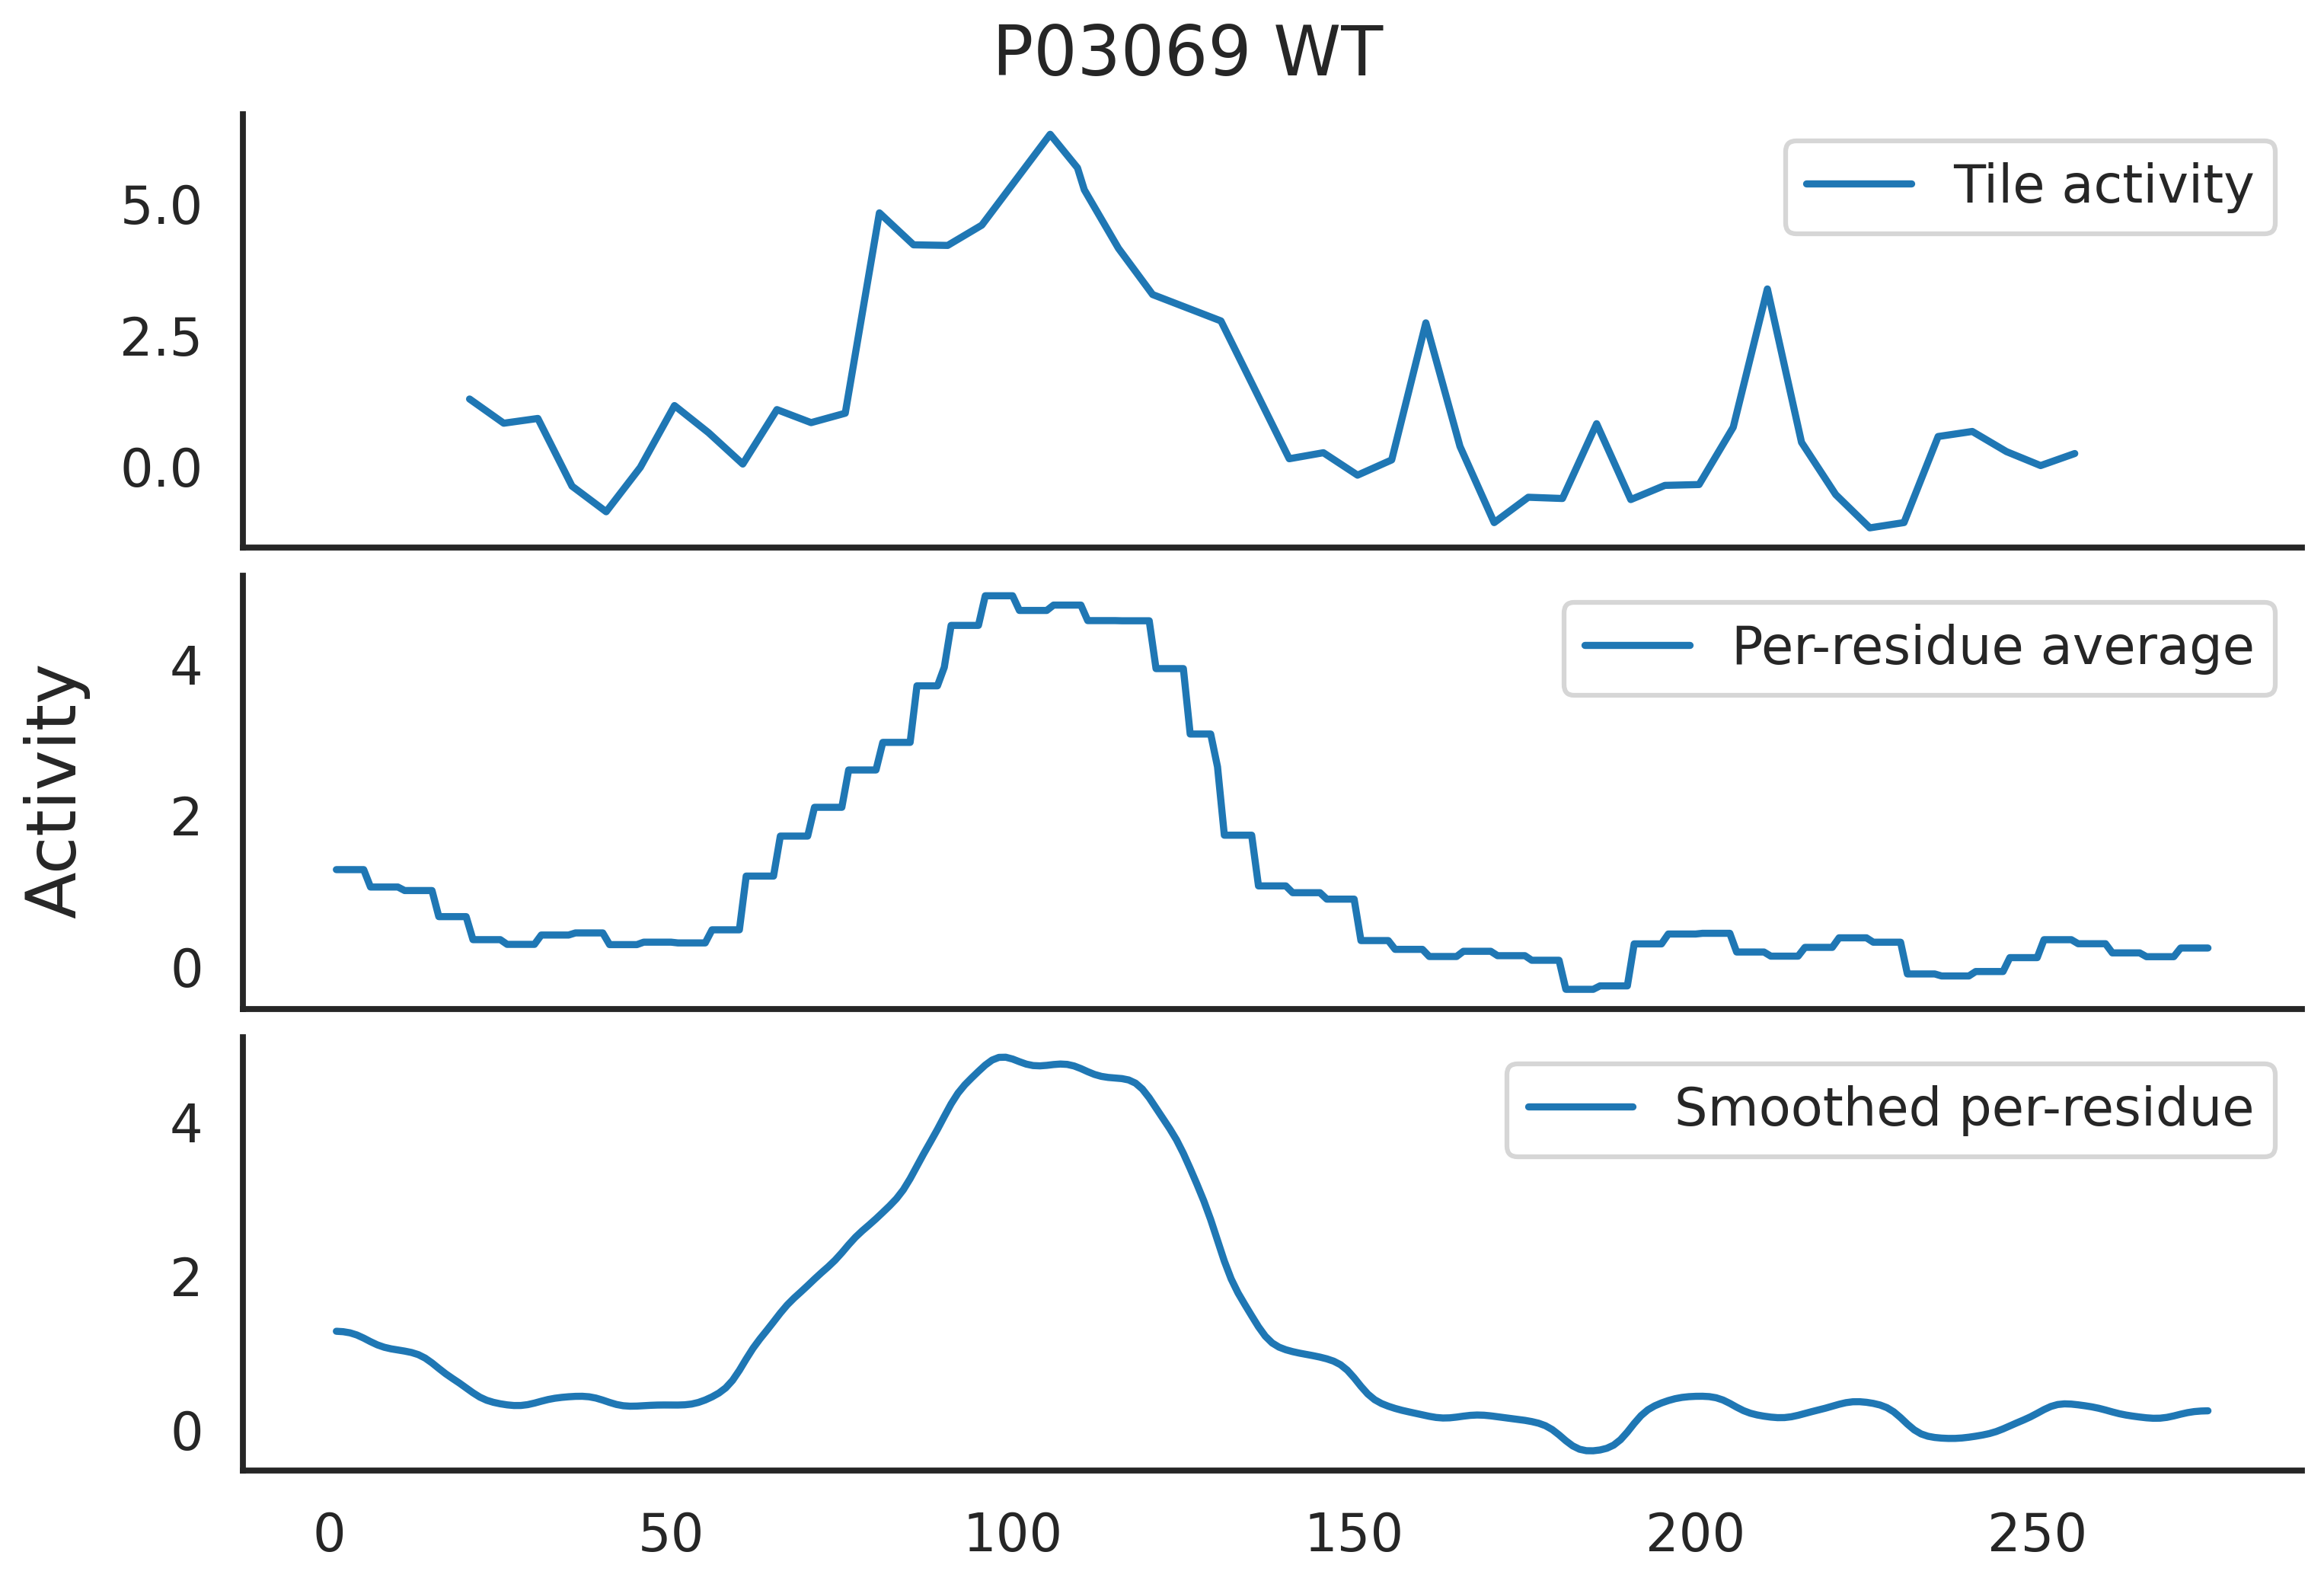

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d

sns.set_context('talk')

def plot_tf_traces(tf_id, activity_col="Activity"):
    """
    Plots 3 vertically stacked traces for a single TF:
    1. Raw tile activity
    2. Per-residue average activity
    3. Smoothed per-residue activity
    """
    fig, axs = plt.subplots(3, 1, sharex=True, figsize=(10,7), dpi=300)
    
    # ---- 1. Raw tile activity (centered tile) ----
    tf_tiles = merged[merged["uniprotID"] == tf_id].sort_values("tile_center")
    sns.lineplot(
        data=tf_tiles, 
        x="tile_center", 
        y="activity", 
        ax=axs[0], 
        label="Tile activity"
    )
    
    # ---- 2. Per-residue average ----
    tf_residues = df_residues[df_residues["uniprotID"] == tf_id].sort_values("position")
    sns.lineplot(
        data=tf_residues, 
        x="position", 
        y="activity_mean", 
        ax=axs[1], 
        label="Per-residue average"
    )
    
    # ---- 3. Smoothed per-residue ----
    smoothed = gaussian_filter1d(tf_residues["activity_mean"].values, sigma=2)
    axs[2].plot(tf_residues["position"], smoothed, label="Smoothed per-residue")
    axs[2].legend()
    
    # ---- Labels ----
    axs[1].set_xlabel("Position")
    axs[0].set_ylabel("")
    axs[1].set_ylabel("")
    fig.supylabel(activity_col, x=-0.01)
    plt.suptitle(f"{tf_id} WT")
    
    sns.despine()
    plt.tight_layout(pad = 0.5)
    plt.show()

# Example usage
plot_tf_traces("P03069", activity_col="Activity")

In [15]:
df = merged.copy()

df["tile_center"] = (df["tile_start"] + df["tile_end"]) / 2

df_mean = (
    df.groupby(["uniprotID", "tile_center"])
    ["activity"]
    .mean()
    .reset_index()
)

df_mean

,uniprotID,tile_center,activity
0,O14467,20.5,-0.006953
1,O14467,25.5,-0.010416
2,O14467,30.5,-0.692145
3,O14467,35.5,-0.023496
4,O14467,40.5,0.069961
...,...,...,...
14957,Q12531,200.5,-0.416587
14958,Q12531,205.5,-0.636396
14959,Q12531,210.5,-1.435502
14960,Q12531,220.5,-0.415368


In [19]:
tf_lengths = (
    df.groupby("uniprotID")["tile_end"]
    .max()
    .sort_values(ascending=False)
)
tf_lengths

uniprotID
P0CE41    1502.0
P39113    1425.0
P46974    1380.0
Q05854    1341.0
P07248    1323.0
           ...  
P0CY10     126.0
P40569     121.0
P0CY13     119.0
P0CY12     119.0
P11633      99.0
Name: tile_end, Length: 154, dtype: float64

In [20]:
heatmap_df = df_mean.pivot(
    index="uniprotID",
    columns="tile_center",
    values="activity"
)

heatmap_df = heatmap_df.loc[tf_lengths.index]
heatmap_df

tile_center,20.5,24.5,25.5,29.5,30.5,34.5,35.5,39.5,40.5,44.5,...,1435.5,1440.5,1445.5,1450.5,1455.5,1465.5,1470.5,1475.5,1480.5,1482.5
uniprotID,,,,,,,,,,,,,,,,,,,,,
P0CE41,0.899161,NaN,0.126312,NaN,-0.023624,NaN,-0.932790,NaN,NaN,NaN,...,2.294046,2.610237,1.930052,0.484279,1.545975,1.112733,0.88898,0.141437,0.033226,0.341312
P39113,-0.844722,NaN,-0.377093,NaN,-0.658803,NaN,-1.073063,NaN,0.082859,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P46974,-0.110569,NaN,0.124367,NaN,0.410583,NaN,0.337895,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Q05854,0.077894,NaN,-1.060955,NaN,-0.444977,NaN,-1.640414,NaN,-0.305138,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P07248,1.574429,NaN,2.668206,NaN,1.830601,NaN,0.618909,NaN,1.353065,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P0CY10,NaN,NaN,1.818465,NaN,1.574429,NaN,4.096089,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P40569,-0.876028,NaN,NaN,NaN,-1.099692,NaN,-1.683375,NaN,0.161757,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P0CY13,-0.345149,-0.508911,0.171483,-2.000605,-0.078149,1.276336,-0.352497,-0.049985,-0.083602,0.276001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


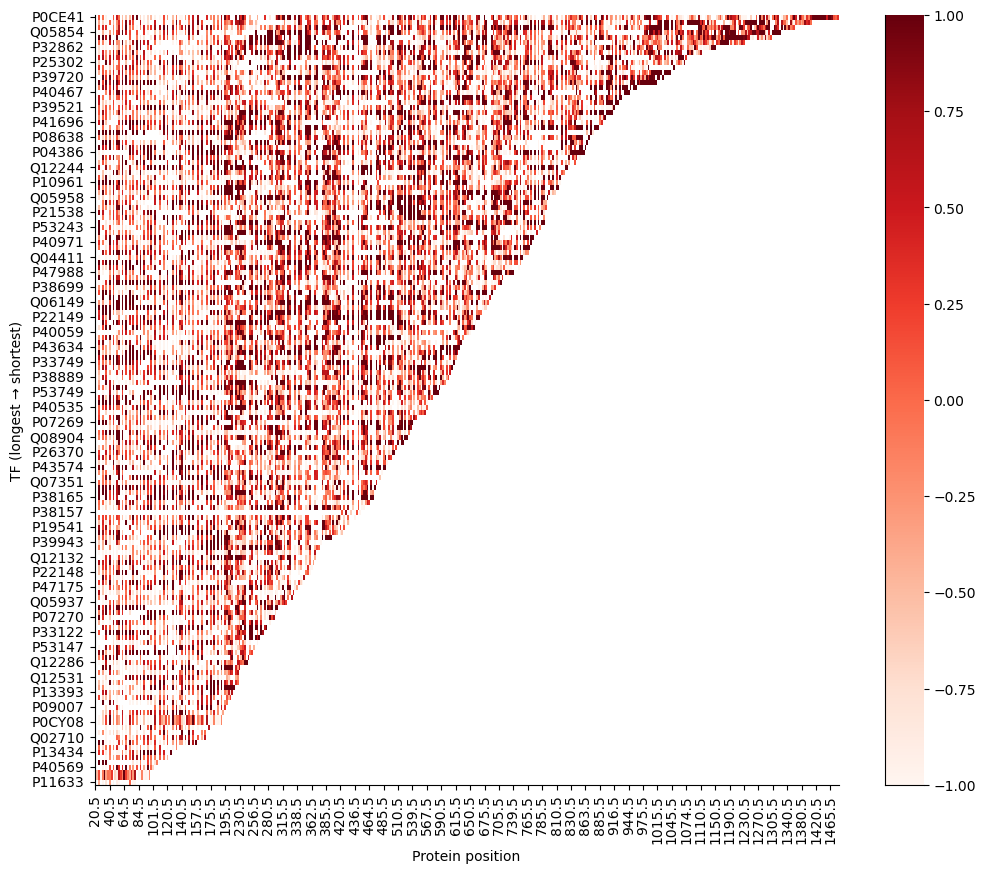

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    heatmap_df,
    cmap="Reds",
    center=0,
    vmin=-1,
    vmax=1
)

plt.xlabel("Protein position")
plt.ylabel("TF (longest → shortest)")
sns.despine()
plt.show()

In [22]:
min(df_residues["activity_mean"])

-3.042080773749258

In [23]:
max(df_residues["activity_mean"])

6.728662699526256

In [24]:
sanborn_ADs = pd.read_excel("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/sanborn_known_ADs_elife-68068-fig1-data2-v3.xlsx")
sanborn_ADs = sanborn_ADs.rename(columns = {"protein ID" : "uniprotID"})
sanborn_ADs

,protein,uniprotID,start,stop,maximal activation,maximal Z score,maximal fragment,sequence
0,GCN4,P03069,63,142,128.273405,11.910003,A_tiles_P03069:76,NLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFE...
1,GAL4,P04386,832,880,44.019965,9.285866,A_tiles_P04386:828,SKPLSPGWTDQTAYNAFGITTGMFNTTTMDDVYNYLFDDEDTPPNPKK
2,GAL4,P04386,146,199,59.660889,10.031831,A_controls-mean_GAL4,SIDSAAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPN...
3,ARG81,P05085,194,256,32.070085,8.508774,A_tiles_P05085:194,KGHVKTGILSANDGVPPTPNLLDYDWNNLNITGYEWISSELRDDAL...
4,ARG81,P05085,69,126,13.391200,6.366012,A_tiles_P05085:65,IPQNSPATTTNLSGSVDEPQYQRRNIDFVRYDEEYVYHEDMDDELT...
...,...,...,...,...,...,...,...,...
145,YRM1,Q12340,737,785,73.486889,10.543228,A_tiles_Q12340:733,SENASHNNETGPIETELAQTISNEFWTAYNLGWEELMSQPDYKYLFDT
146,YRM1,Q12340,184,241,21.275056,7.501859,A_tiles_Q12340:193,PLEKTGSDILQQVCNVLPSFEQSSKIITDFFNTELETNEVSEVLDK...
147,HAA1,Q12753,658,693,35.587427,8.764113,A_tiles_Q12753:641,DLPDTSPMSSIQTASPPSQLLTDQGFADLDNFMSS
148,HAA1,Q12753,274,335,28.366703,8.207702,A_tiles_Q12753:282,NSRVGEVSVPLEEYIPSDIDGVGRVTDKSSLVYDWPFDESIERNFS...


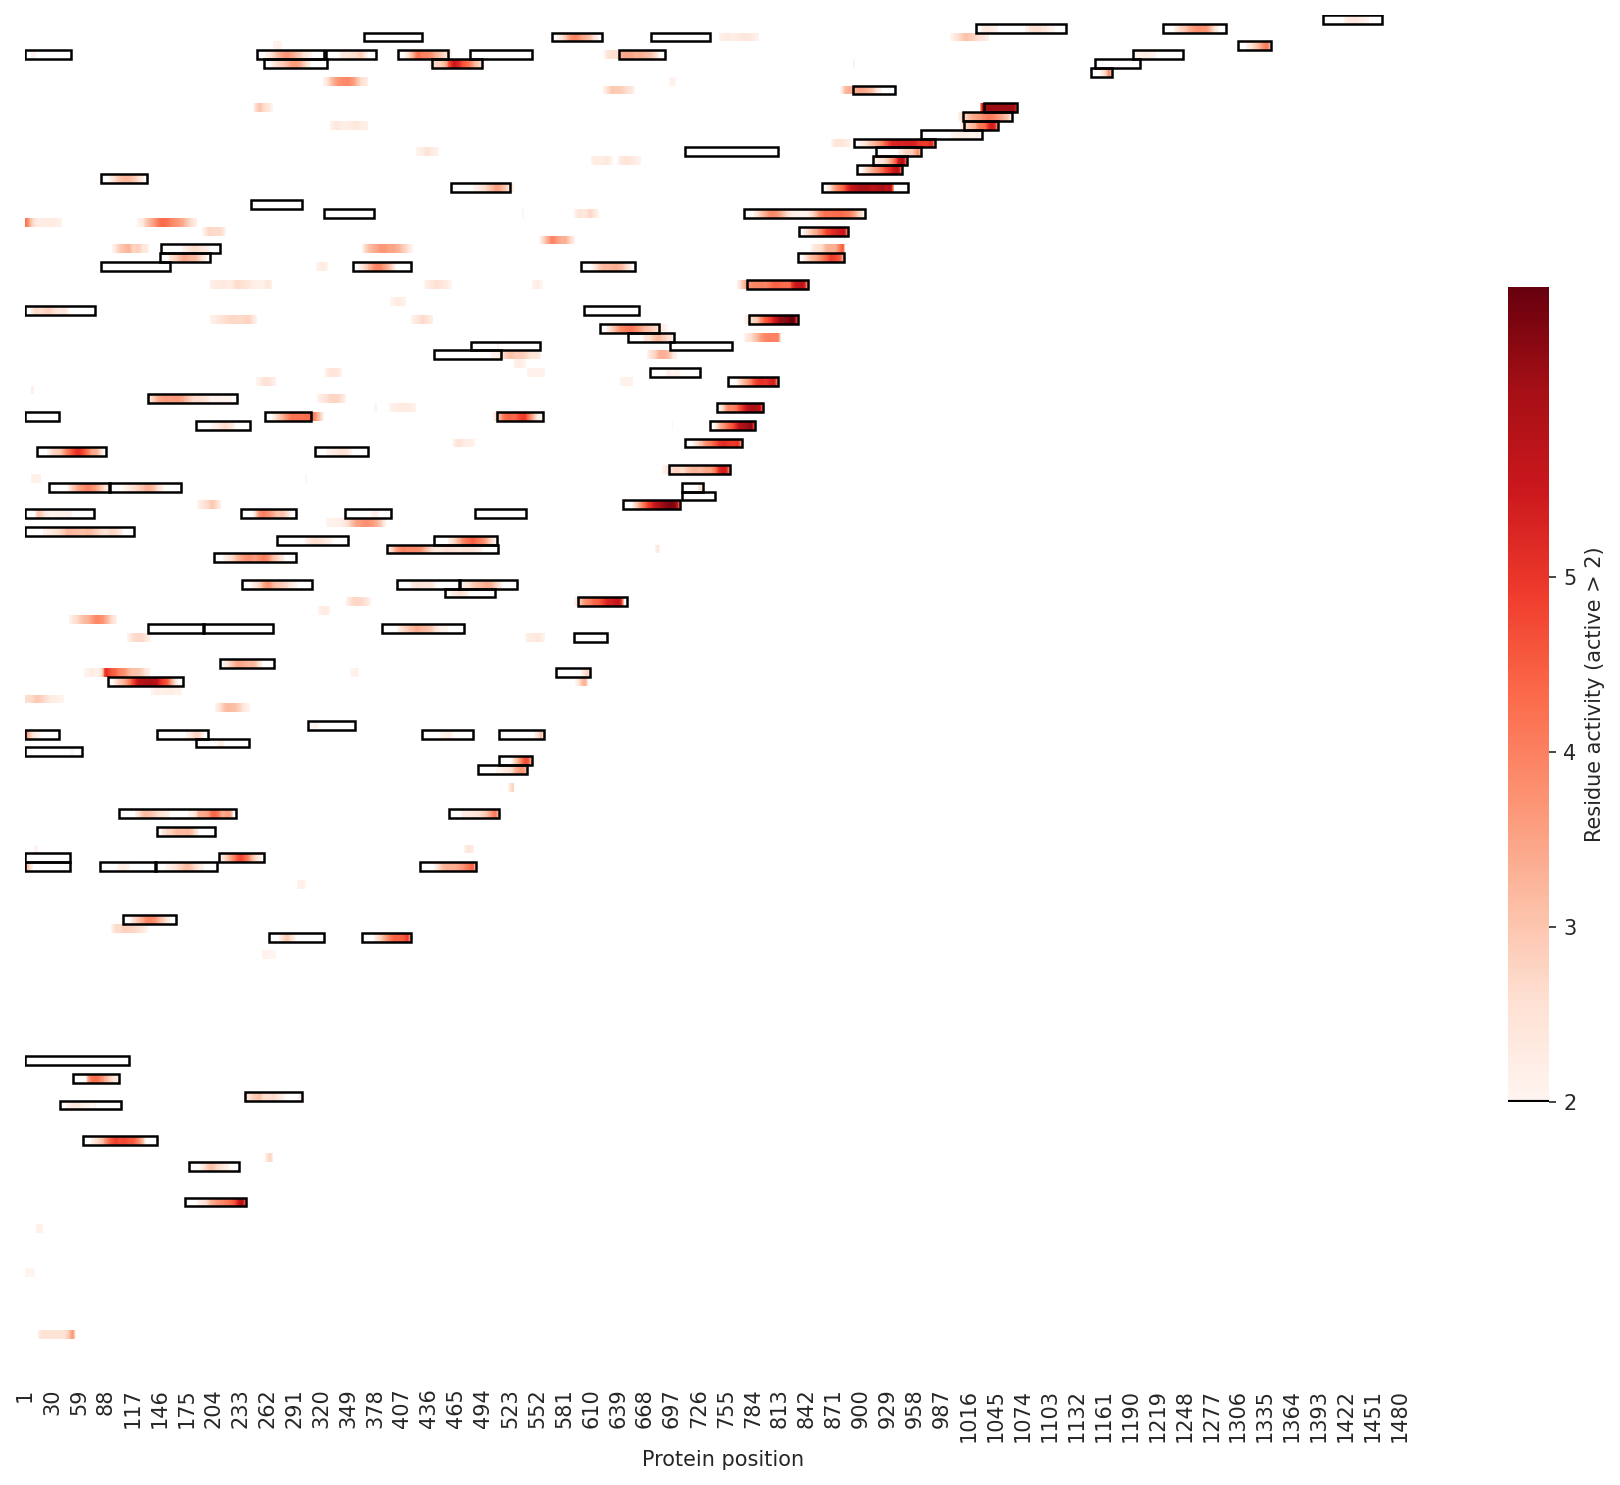

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize

# -------------------------
# 1. Determine TF order
tf_lengths = df.groupby("uniprotID")["tile_end"].max().sort_values(ascending=False)

# -------------------------
# 2. Pivot df_residues
heatmap_df = df_residues.pivot(
    index="uniprotID",
    columns="position",
    values="activity_mean"
)

heatmap_df = heatmap_df.loc[tf_lengths.index]

# -------------------------
# 3. Smooth each row without affecting NaNs
heatmap_array = heatmap_df.values
nan_mask = np.isnan(heatmap_array)

heatmap_filled = np.where(nan_mask, 0, heatmap_array)

smoothed_array = gaussian_filter1d(
    heatmap_filled,
    sigma=2,
    axis=1
)

smoothed_array[nan_mask] = np.nan

smoothed_heatmap = pd.DataFrame(
    smoothed_array,
    index=heatmap_df.index,
    columns=heatmap_df.columns
)

# -------------------------
# 4. Mask inactive residues (≤2)
threshold = 2

smoothed_heatmap_masked = smoothed_heatmap.where(
    smoothed_heatmap > threshold
)

# -------------------------
# 5. Colormap setup
cmap = sns.color_palette("Reds", as_cmap=True)
cmap.set_under("white")

norm = Normalize(
    vmin=threshold,
    vmax=np.nanmax(smoothed_heatmap_masked)
)

# -------------------------
# 6. Plot heatmap
sns.set_style("white")

fig, ax = plt.subplots(
    figsize=(12,10),
    dpi=150
)

hm = sns.heatmap(
    smoothed_heatmap_masked,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={
        "label": "Residue activity",
        "shrink": 0.6
    },
    ax=ax
)

# -------------------------
# 7. Format axes
plt.yticks([])
plt.ylabel("")
plt.xlabel("Protein position")

plt.gcf().patch.set_facecolor('white')

# -------------------------
# 8. Highlight activation threshold on colorbar
cbar = hm.collections[0].colorbar

cbar.ax.axhline(
    threshold,
    color="black",
    lw=2
)

cbar.set_label("Residue activity (active > 2)")

# optional cleaner ticks
cbar.set_ticks([
    threshold,
    threshold+1,
    threshold+2,
    threshold+3
])

# -------------------------
# 9. Overlay AD boxes
for _, ad in sanborn_ADs.iterrows():

    uniprot = ad["uniprotID"]
    start = ad["start"]
    end = ad["stop"]

    if uniprot not in heatmap_df.index:
        continue

    row_idx = heatmap_df.index.get_loc(uniprot)

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="black",
        facecolor="none",
        lw=1.2
    )

    ax.add_patch(rect)

plt.tight_layout()
plt.show()

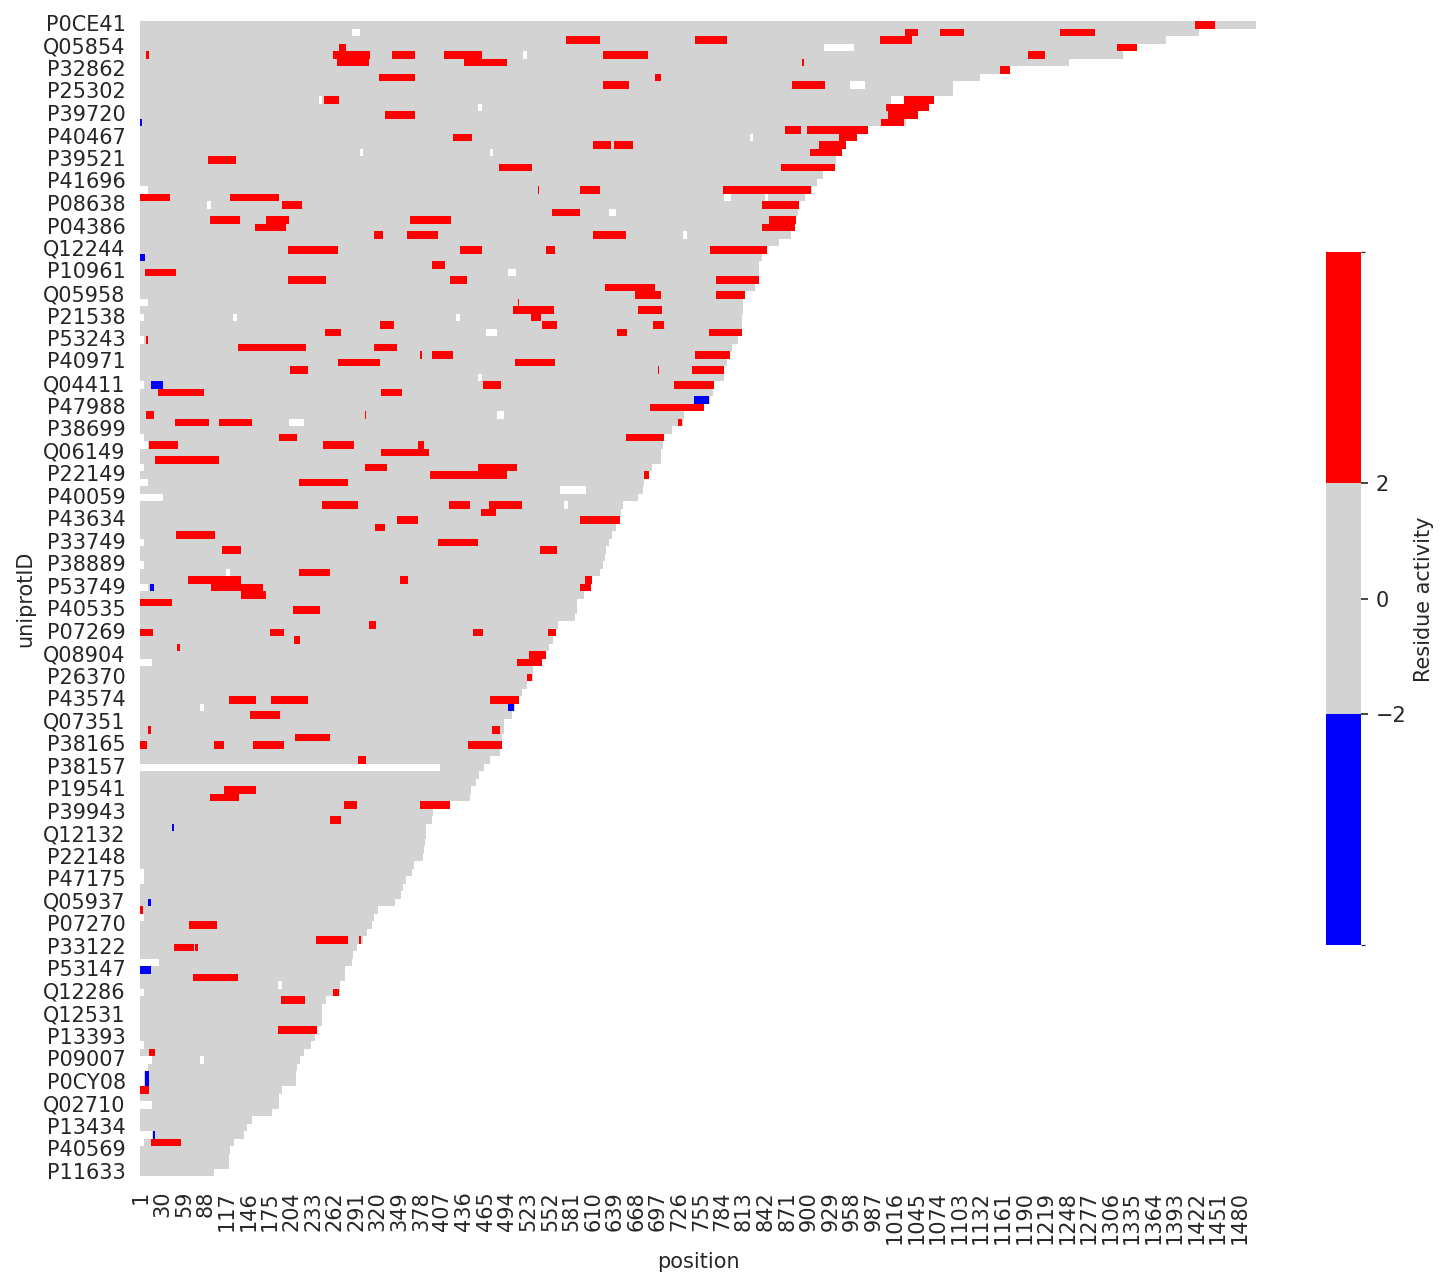

In [29]:
from matplotlib.colors import ListedColormap, BoundaryNorm

neg_thresh = -2
pos_thresh = 2

# Get finite data range (ignore NaNs)
data_min = np.nanmin(smoothed_heatmap.values)
data_max = np.nanmax(smoothed_heatmap.values)

# Make sure bounds extend beyond thresholds
lower = min(data_min, neg_thresh - 1)
upper = max(data_max, pos_thresh + 1)

# Define discrete colormap
cmap = ListedColormap(["blue", "lightgray", "red"])

# Use FINITE bounds (this fixes your crash)
bounds = [lower, neg_thresh, pos_thresh, upper]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(12,10), dpi=150)

hm = sns.heatmap(
    smoothed_heatmap,   # <-- NOT masked anymore
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={
        "label": "Residue activity",
        "shrink": 0.6,
        "ticks": [neg_thresh, 0, pos_thresh]
    },
    ax=ax
)
plt.show()

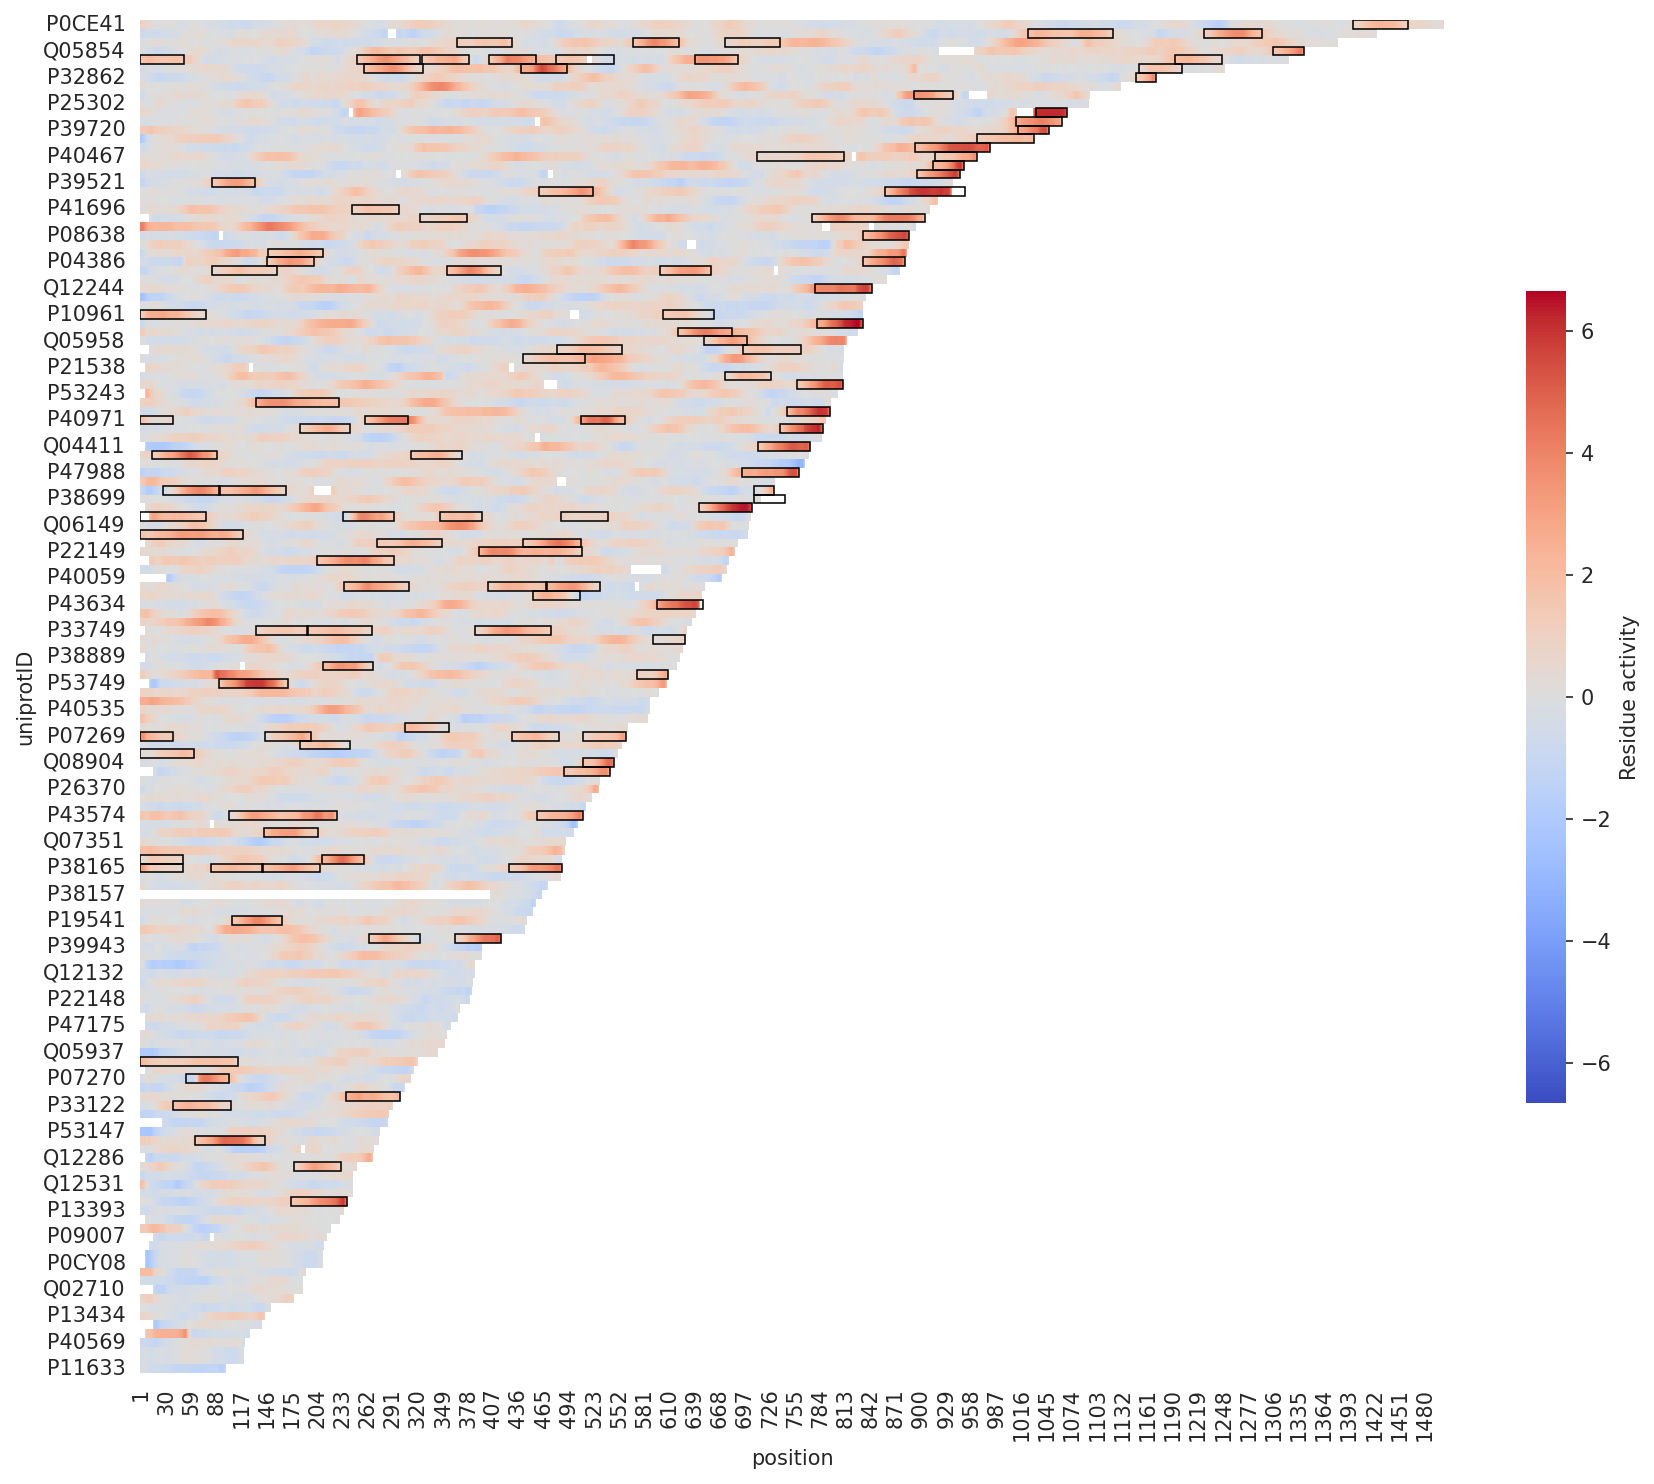

In [63]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt

#data_min = np.nanmin(smoothed_heatmap.values)
data_max = np.nanmax(smoothed_heatmap.values)

norm = TwoSlopeNorm(
    vmin=-1 * data_max,
    vcenter=0,
    vmax=data_max
)

cmap = plt.get_cmap("coolwarm")

fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

hm = sns.heatmap(
    smoothed_heatmap,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={
        "label": "Residue activity",
        "shrink": 0.6
    },
    ax=ax
)

for _, ad in sanborn_ADs.iterrows():

    uniprot = ad["uniprotID"]
    start = ad["start"]
    end = ad["stop"]

    if uniprot not in heatmap_df.index:
        continue

    row_idx = heatmap_df.index.get_loc(uniprot)

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="black",
        facecolor="none",
        lw=0.75
    )

    ax.add_patch(rect)


plt.tight_layout()
plt.show()

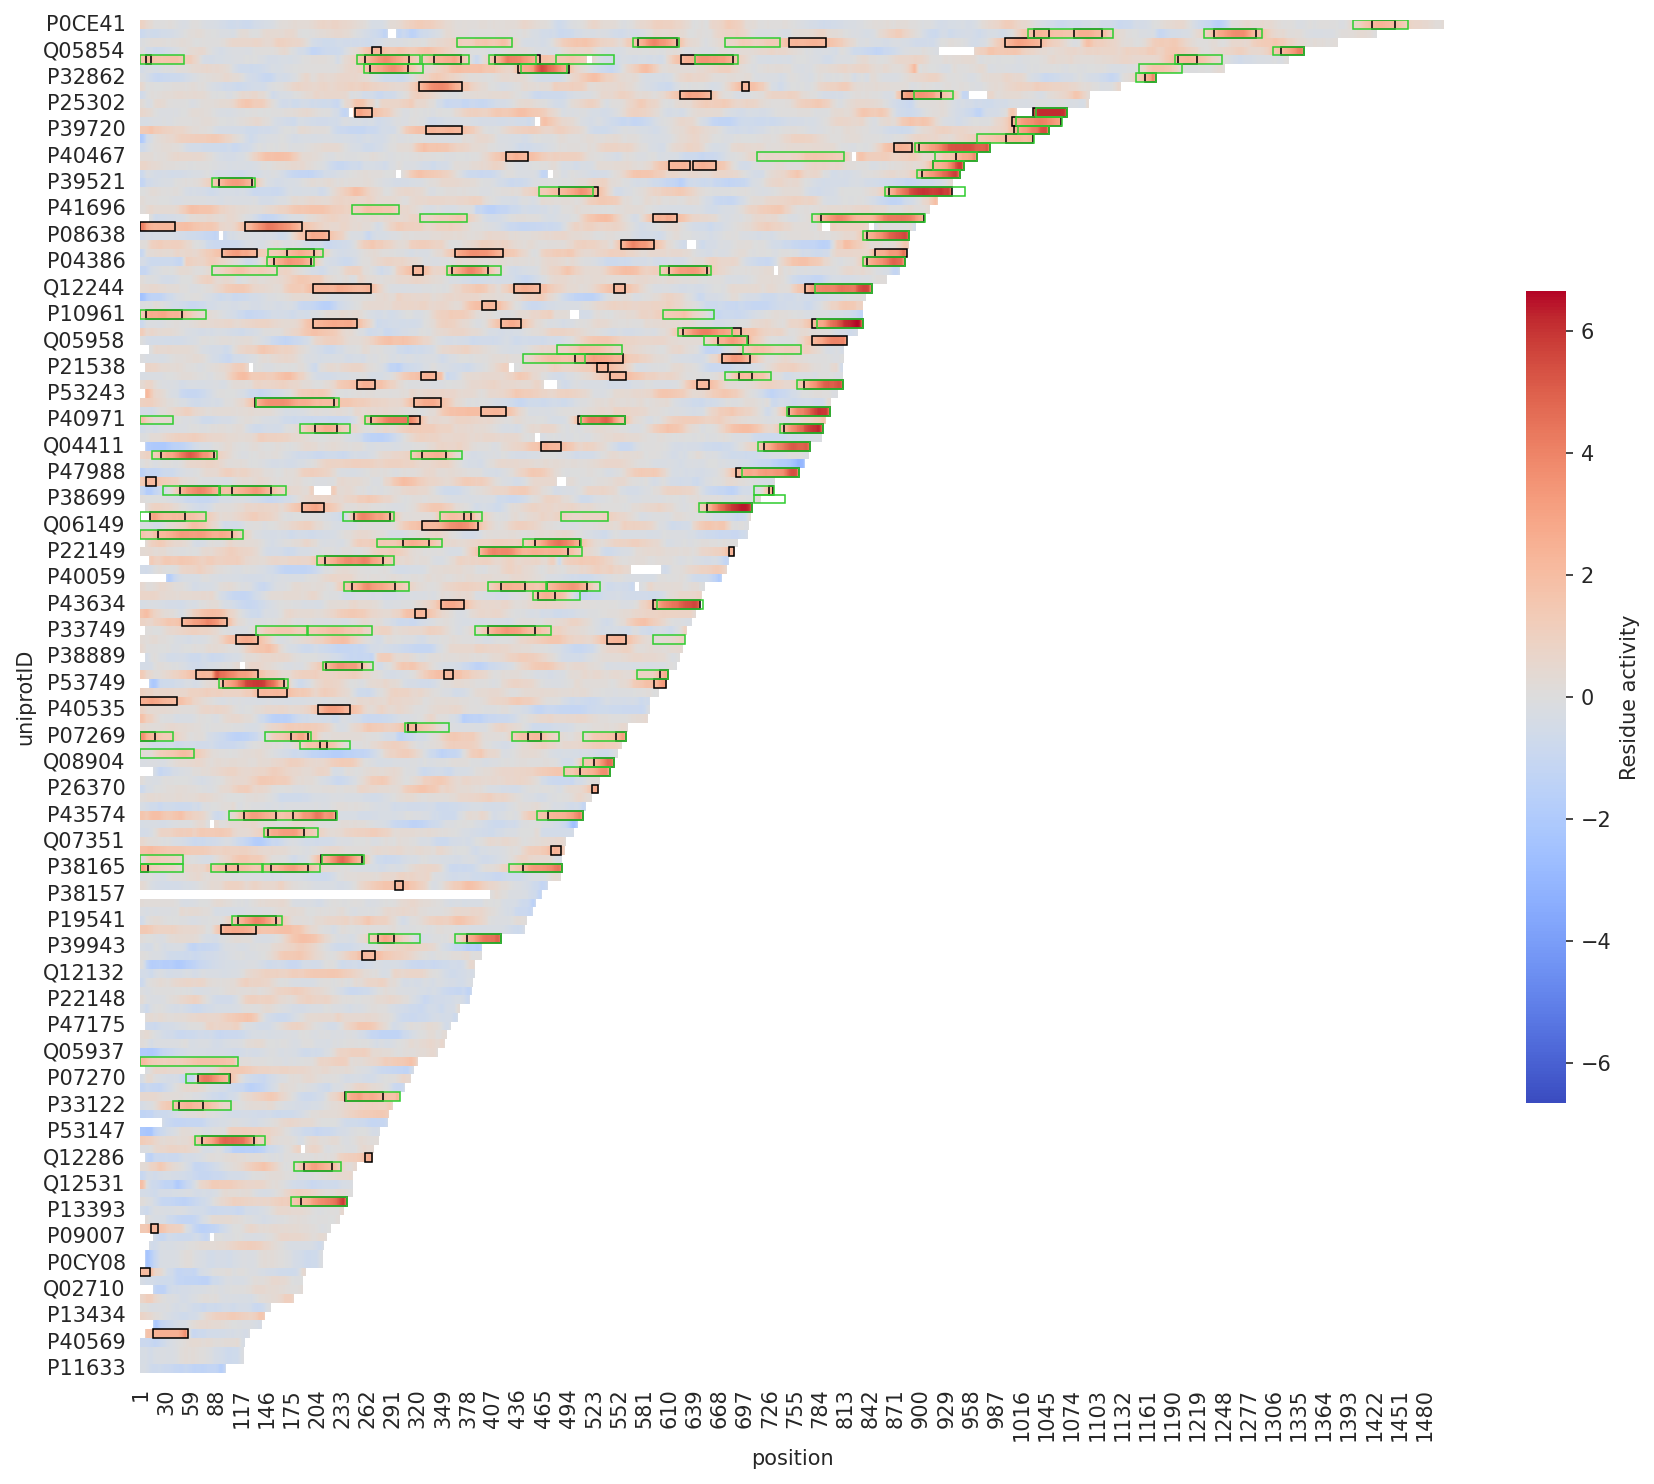

In [66]:
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import numpy as np

# zero-centered normalization
data_max = np.nanmax(smoothed_heatmap.values)
norm = TwoSlopeNorm(vmin=-data_max, vcenter=0, vmax=data_max)
cmap = plt.get_cmap("coolwarm")

fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

# draw heatmap
hm = sns.heatmap(
    smoothed_heatmap,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={"label": "Residue activity", "shrink": 0.6},
    ax=ax
)

# iterate over each protein (row)
for row_idx, uniprot in enumerate(smoothed_heatmap.index):
    row_data = smoothed_heatmap.loc[uniprot].values
    above_thresh = row_data > 2  # boolean array

    # find consecutive stretches above threshold
    in_region = False
    start_idx = None
    for i, val in enumerate(above_thresh):
        if val and not in_region:
            in_region = True
            start_idx = i
        elif not val and in_region:
            in_region = False
            if i - start_idx >= 5:  # keep regions ≥5 residues
                rect = Rectangle(
                    (start_idx, row_idx),
                    width=i - start_idx,
                    height=1,
                    edgecolor="black",
                    facecolor="none",
                    lw=0.75
                )
                ax.add_patch(rect)
    # handle region that goes to the end
    if in_region and len(row_data) - start_idx >= 5:
        rect = Rectangle(
            (start_idx, row_idx),
            width=len(row_data) - start_idx,
            height=1,
            edgecolor="black",
            facecolor="none",
            lw=0.75
        )
        ax.add_patch(rect)

for _, ad in sanborn_ADs.iterrows():

    uniprot = ad["uniprotID"]
    start = ad["start"]
    end = ad["stop"]

    if uniprot not in heatmap_df.index:
        continue

    row_idx = heatmap_df.index.get_loc(uniprot)

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="limegreen",
        facecolor="none",
        lw=0.75
    )

    ax.add_patch(rect)



plt.tight_layout()
plt.show()

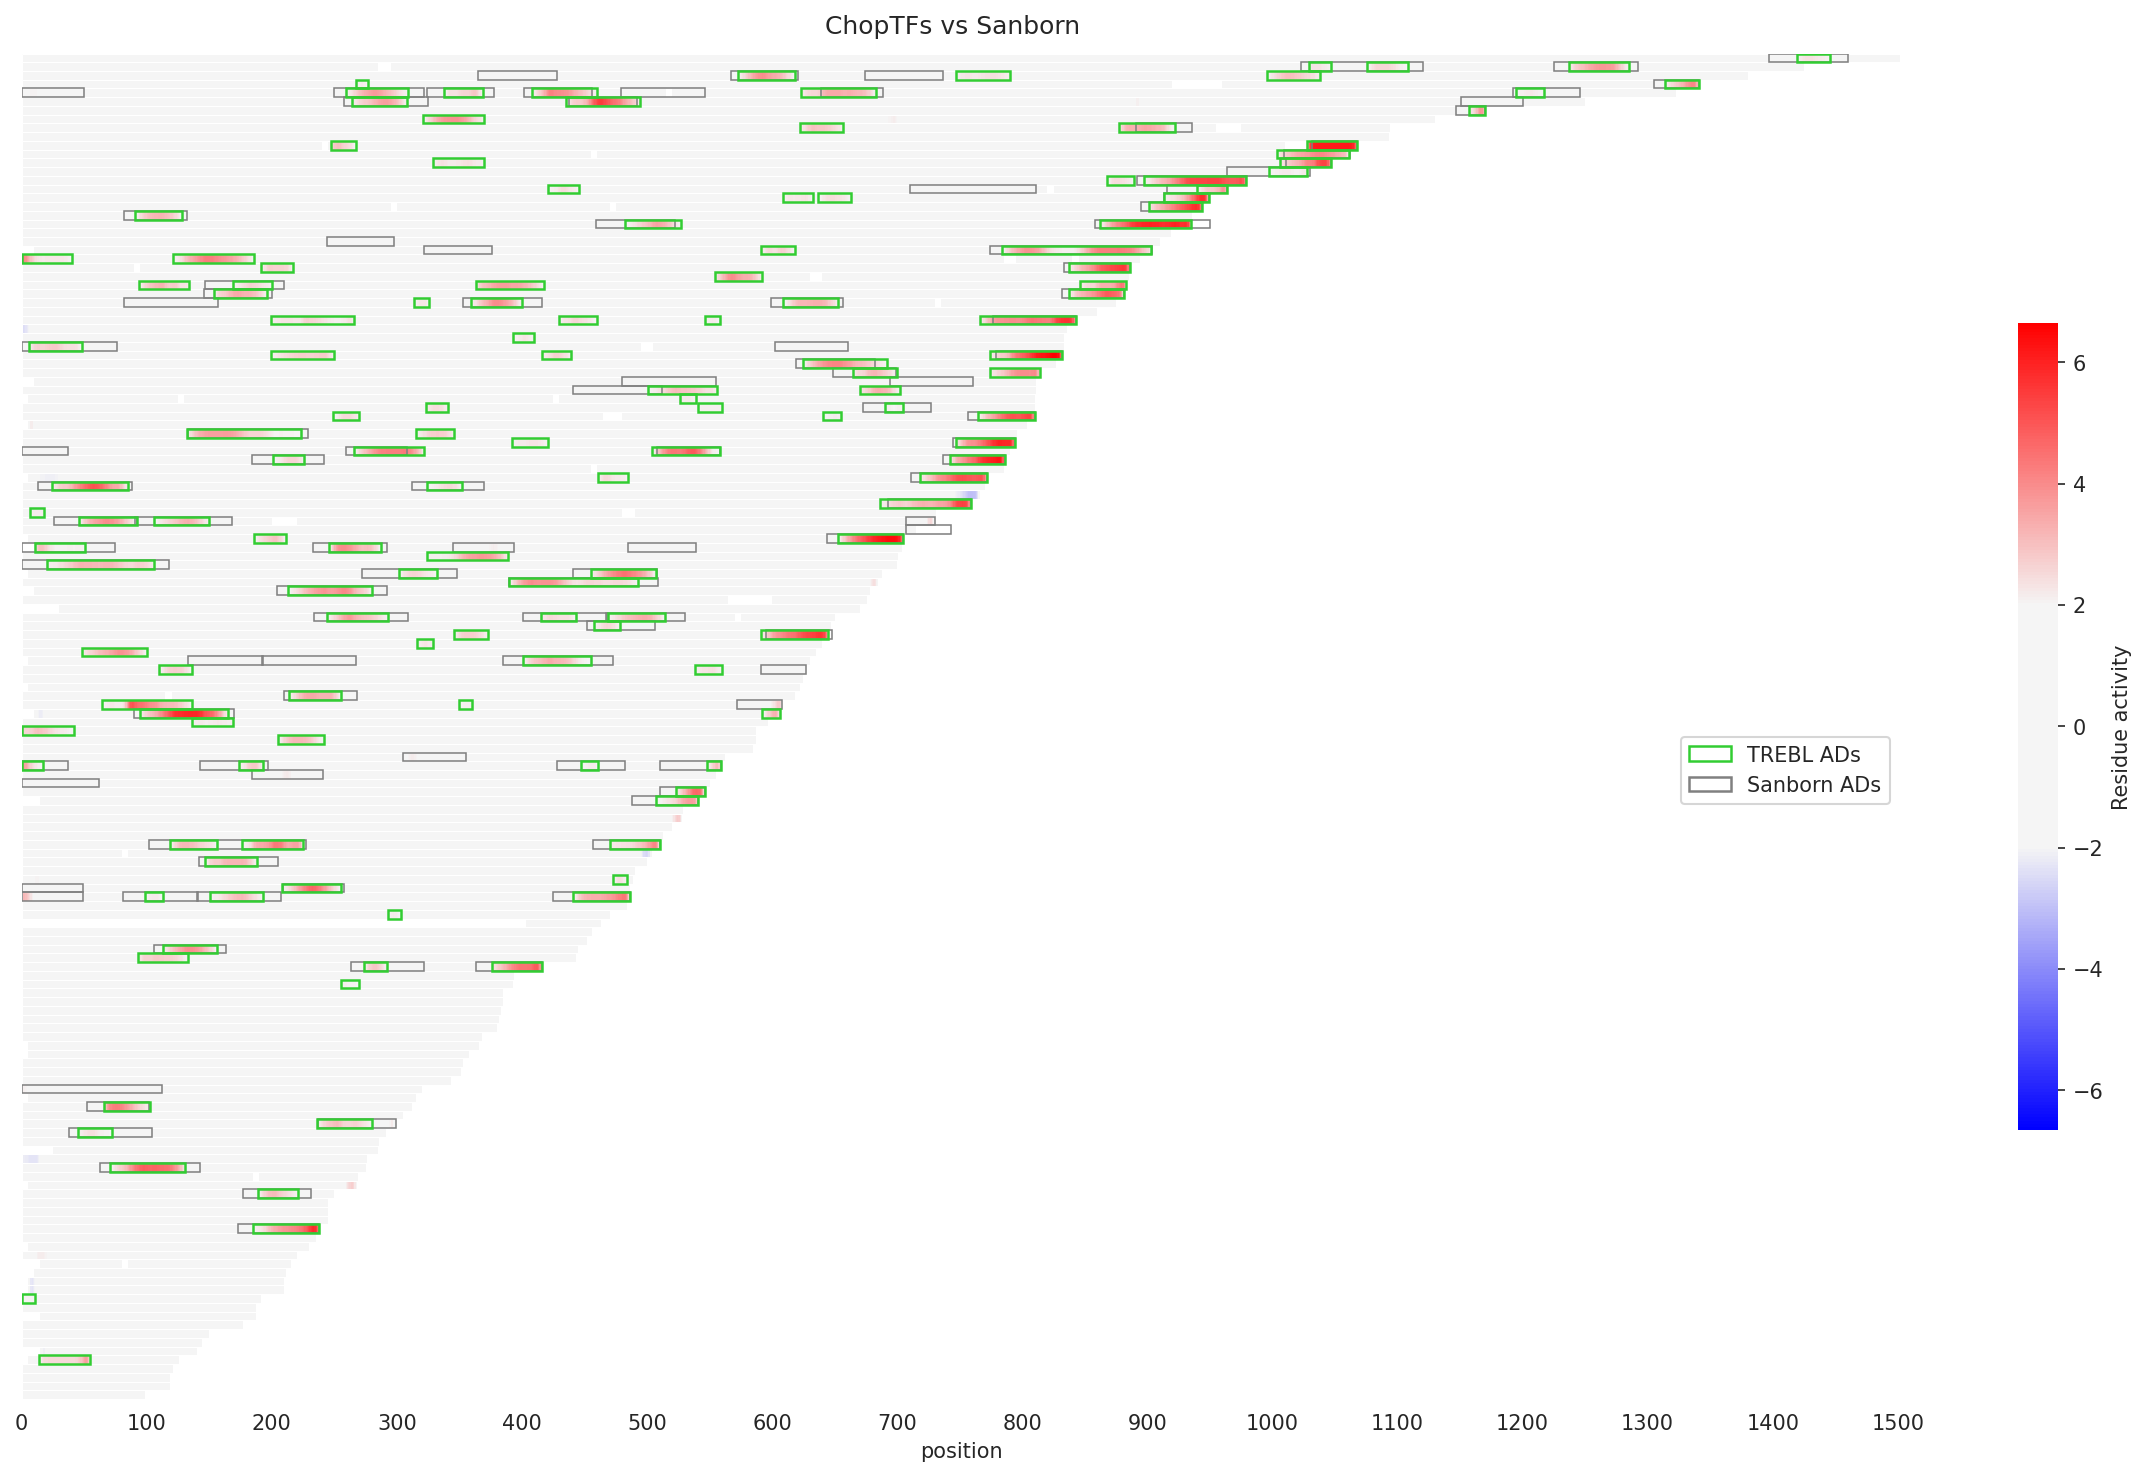

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle

neg_thresh = -2
pos_thresh = 2

data_min = np.nanmin(smoothed_heatmap.values)
data_max = np.nanmax(smoothed_heatmap.values)

# --- make symmetric
lim = max(abs(data_min), abs(data_max))
norm = Normalize(vmin=-lim, vmax=lim)

# positions in [0,1]
p_neg = norm(neg_thresh)
p_pos = norm(pos_thresh)

# --- colormap
cmap = LinearSegmentedColormap.from_list(
    "custom_blue_gray_red",
    [
        (0.0, "blue"),
        (p_neg, "whitesmoke"),
        (p_pos, "whitesmoke"),
        (1.0, "red")
    ]
)

fig, ax = plt.subplots(figsize=(16,10), dpi=150)

hm = sns.heatmap(
    smoothed_heatmap,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={"label": "Residue activity", "shrink": 0.6},
    ax=ax
)

# --- white border around each TF row
for row_idx in range(len(smoothed_heatmap.index)):
    rect = Rectangle(
        (0, row_idx),
        width=smoothed_heatmap.shape[1],
        height=1,
        edgecolor="white",
        facecolor="none",
        lw=0.5
    )
    ax.add_patch(rect)

# --- draw Sanborn ADs first (background)
for _, ad in sanborn_ADs.iterrows():
    uniprot = ad["uniprotID"]
    start = ad["start"]
    end = ad["stop"]

    if uniprot not in heatmap_df.index:
        continue

    row_idx = heatmap_df.index.get_loc(uniprot)

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="gray",
        facecolor="none",
        lw=0.75
    )
    ax.add_patch(rect)

# --- draw newly detected ADs on top
for row_idx, uniprot in enumerate(smoothed_heatmap.index):
    row_data = smoothed_heatmap.loc[uniprot].values
    above_thresh = row_data > 2

    in_region = False
    start_idx = None
    for i, val in enumerate(above_thresh):
        if val and not in_region:
            in_region = True
            start_idx = i
        elif not val and in_region:
            in_region = False
            if i - start_idx >= 10:
                rect = Rectangle(
                    (start_idx, row_idx),
                    width=i - start_idx,
                    height=1,
                    edgecolor="limegreen",
                    facecolor="none",
                    lw=1.2
                )
                ax.add_patch(rect)
    if in_region and len(row_data) - start_idx >= 10:
        rect = Rectangle(
            (start_idx, row_idx),
            width=len(row_data) - start_idx,
            height=1,
            edgecolor="limegreen",
            facecolor="none",
            lw=1.2
        )
        ax.add_patch(rect)

# --- remove full x-axis labels
ax.set_yticklabels([])
ax.set_ylabel("")

# x ticks
n_cols = smoothed_heatmap.shape[1]

# set x-ticks every 50 residues
xticks = np.arange(0, n_cols, 100)
ax.set_xticks(xticks)

# optionally label them with actual residue numbers
ax.set_xticklabels(xticks)  # +1 if residue indexing starts at 1

# rotate if needed for readability
plt.xticks(rotation=0)

fig.suptitle("ChopTFs vs Sanborn", x= 0.4)

from matplotlib.patches import Patch

# --- create a legend patch for newly detected ADs
new_ad_patch = Patch(
    edgecolor="limegreen",
    facecolor="none",
    lw=1.2,
    label="TREBL ADs"
)

old_ad_patch = Patch(
    edgecolor="gray",
    facecolor="none",
    lw=1.2,
    label="Sanborn ADs"
)

# add legend to the heatmap
ax.legend(
    handles=[new_ad_patch, old_ad_patch],
    loc="upper right",  # adjust as needed
    fontsize=10,
    bbox_to_anchor = (1,0.5)
)

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle

neg_thresh = -2
pos_thresh = 2

data_min = np.nanmin(smoothed_heatmap.values)
data_max = np.nanmax(smoothed_heatmap.values)

# --- make symmetric
lim = max(abs(data_min), abs(data_max))
norm = Normalize(vmin=-lim, vmax=lim)

# positions in [0,1]
p_neg = norm(neg_thresh)
p_pos = norm(pos_thresh)

# --- colormap
cmap = LinearSegmentedColormap.from_list(
    "custom_blue_gray_red",
    [
        (0.0, "blue"),
        (p_neg, "whitesmoke"),
        (p_pos, "whitesmoke"),
        (1.0, "red")
    ]
)

fig, ax = plt.subplots(figsize=(16,10), dpi=150)

hm = sns.heatmap(
    smoothed_heatmap,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={"label": "Residue activity", "shrink": 0.6},
    ax=ax
)

# --- white border around each TF row
for row_idx in range(len(smoothed_heatmap.index)):
    rect = Rectangle(
        (0, row_idx),
        width=smoothed_heatmap.shape[1],
        height=1,
        edgecolor="white",
        facecolor="none",
        lw=0.5
    )
    ax.add_patch(rect)

# --- draw Sanborn ADs first (background)
for _, ad in sanborn_ADs.iterrows():
    uniprot = ad["uniprotID"]
    start = ad["start"]
    end = ad["stop"]

    if uniprot not in heatmap_df.index:
        continue

    row_idx = heatmap_df.index.get_loc(uniprot)

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="gray",
        facecolor="none",
        lw=0.75
    )
    ax.add_patch(rect)

# --- draw newly detected ADs on top
# for row_idx, uniprot in enumerate(smoothed_heatmap.index):
#     row_data = smoothed_heatmap.loc[uniprot].values
#     above_thresh = row_data > 2

#     in_region = False
#     start_idx = None
#     for i, val in enumerate(above_thresh):
#         if val and not in_region:
#             in_region = True
#             start_idx = i
#         elif not val and in_region:
#             in_region = False
#             if i - start_idx >= 10:
#                 rect = Rectangle(
#                     (start_idx, row_idx),
#                     width=i - start_idx,
#                     height=1,
#                     edgecolor="limegreen",
#                     facecolor="none",
#                     lw=1.2
#                 )
#                 ax.add_patch(rect)
#     if in_region and len(row_data) - start_idx >= 10:
#         rect = Rectangle(
#             (start_idx, row_idx),
#             width=len(row_data) - start_idx,
#             height=1,
#             edgecolor="limegreen",
#             facecolor="none",
#             lw=1.2
#         )
#         ax.add_patch(rect)

# --- remove full x-axis labels
ax.set_yticklabels([])
ax.set_ylabel("")

# x ticks
n_cols = smoothed_heatmap.shape[1]

# set x-ticks every 50 residues
xticks = np.arange(0, n_cols, 100)
ax.set_xticks(xticks)

# optionally label them with actual residue numbers
ax.set_xticklabels(xticks)  # +1 if residue indexing starts at 1

# rotate if needed for readability
plt.xticks(rotation=0)

fig.suptitle("ChopTFs vs Sanborn", x= 0.4)

from matplotlib.patches import Patch

# --- create a legend patch for newly detected ADs
new_ad_patch = Patch(
    edgecolor="limegreen",
    facecolor="none",
    lw=1.2,
    label="TREBL ADs"
)

old_ad_patch = Patch(
    edgecolor="gray",
    facecolor="none",
    lw=1.2,
    label="Sanborn ADs"
)

# add legend to the heatmap
ax.legend(
    handles=[new_ad_patch, old_ad_patch],
    loc="upper right",  # adjust as needed
    fontsize=10,
    bbox_to_anchor = (1,0.5)
)

plt.tight_layout()
plt.show()

NameError: name 'smoothed_heatmap' is not defined

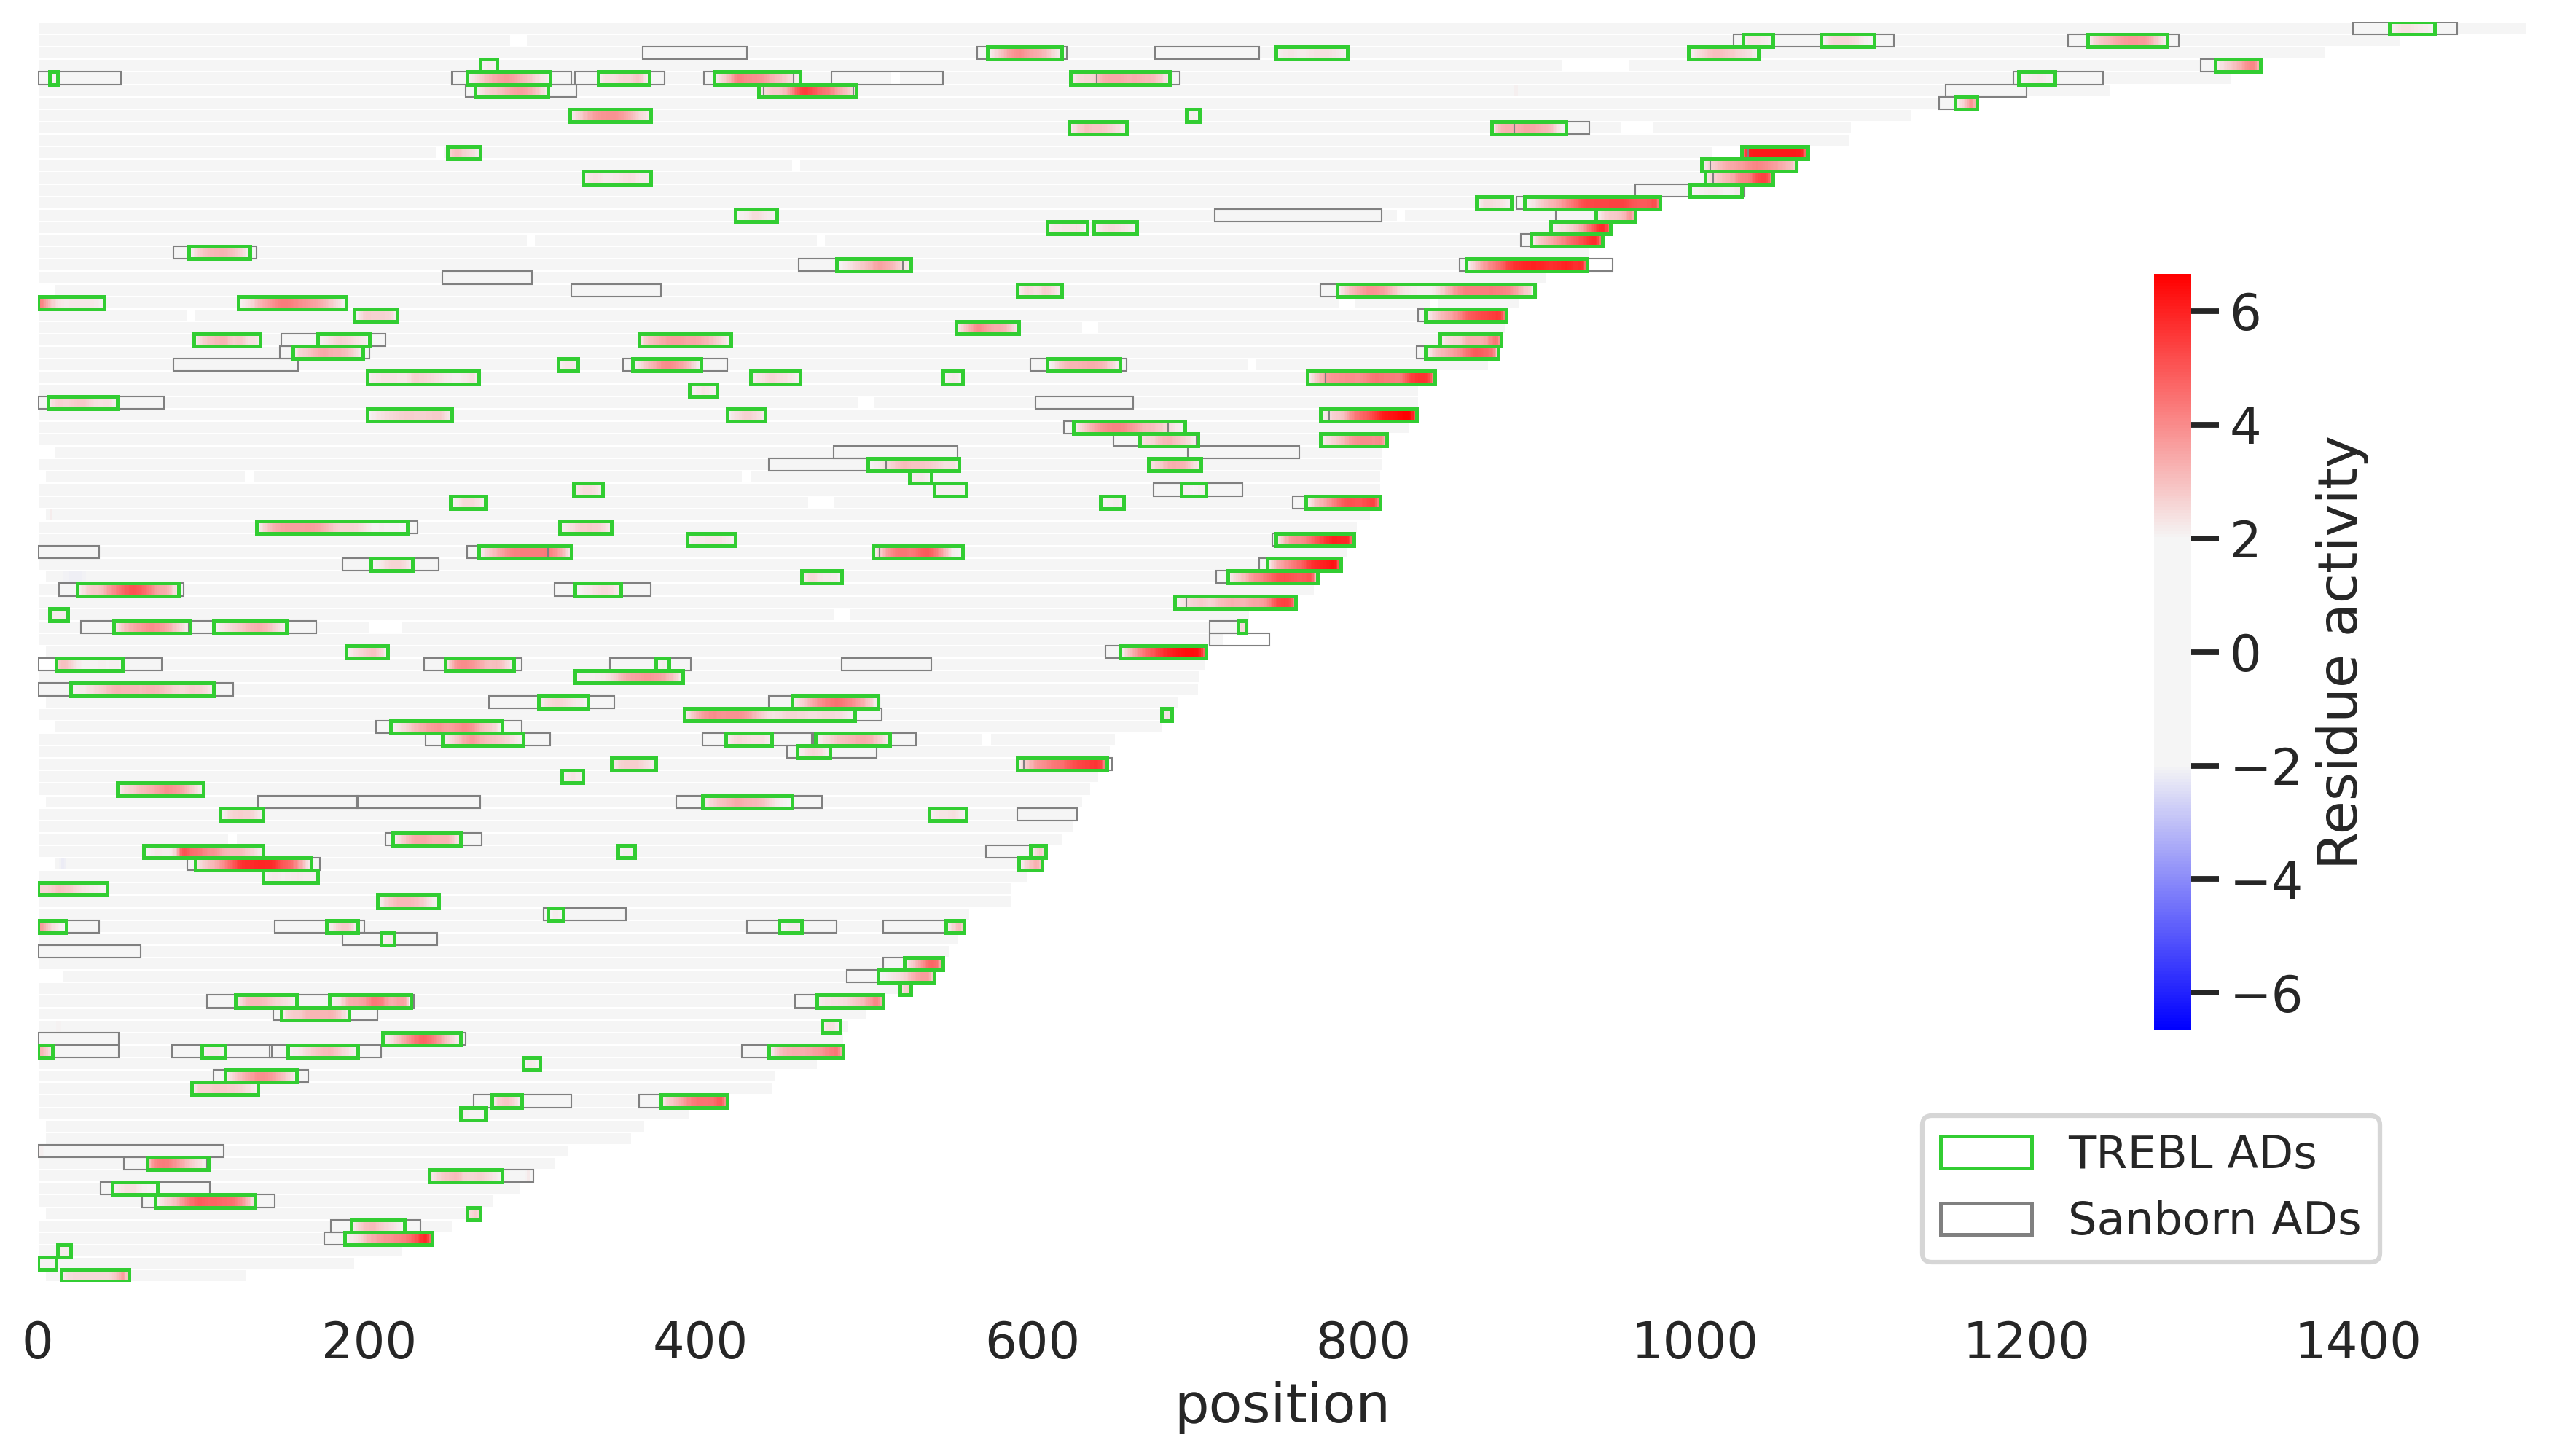

In [150]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle
import seaborn as sns
from matplotlib.patches import Patch

sns.set_context('talk')

neg_thresh = -2
pos_thresh = 2

# --- Identify TFs with Sanborn ADs
sanborn_tfs = set(sanborn_ADs["uniprotID"])

# --- Identify TFs with TREBL ADs (newly detected ADs)
trebl_tfs = []
for uniprot in smoothed_heatmap.index:
    row_data = smoothed_heatmap.loc[uniprot].values
    above_thresh = row_data > 1.5

    in_region = False
    start_idx = None
    for i, val in enumerate(above_thresh):
        if val and not in_region:
            in_region = True
            start_idx = i
        elif not val and in_region:
            in_region = False
            if i - start_idx >= 10:
                trebl_tfs.append(uniprot)
    if in_region and len(row_data) - start_idx >= 10:
        trebl_tfs.append(uniprot)

trebl_tfs = set(trebl_tfs)

# --- Keep only TFs that have Sanborn or TREBL ADs
keep_tfs = list(sanborn_tfs.union(trebl_tfs))
filtered_heatmap = smoothed_heatmap.loc[smoothed_heatmap.index.isin(keep_tfs)]

# --- Normalize and colormap
data_min = np.nanmin(filtered_heatmap.values)
data_max = np.nanmax(filtered_heatmap.values)
lim = max(abs(data_min), abs(data_max))
norm = Normalize(vmin=-lim, vmax=lim)

p_neg = norm(neg_thresh)
p_pos = norm(pos_thresh)

cmap = LinearSegmentedColormap.from_list(
    "custom_blue_gray_red",
    [
        (0.0, "blue"),
        (p_neg, "whitesmoke"),
        (p_pos, "whitesmoke"),
        (1.0, "red")
    ]
)

# --- Plot
fig, ax = plt.subplots(figsize=(12,7), dpi=300)
hm = sns.heatmap(
    filtered_heatmap,
    cmap=cmap,
    norm=norm,
    linewidths=0,
    cbar_kws={"label": "Residue activity", "shrink": 0.6, "pad" : -0.15},
    ax=ax
)

# --- White border around each TF row
for row_idx in range(len(filtered_heatmap.index)):
    rect = Rectangle(
        (0, row_idx),
        width=filtered_heatmap.shape[1],
        height=1,
        edgecolor="white",
        facecolor="none",
        lw=0.5
    )
    ax.add_patch(rect)

# --- Sanborn ADs
for _, ad in sanborn_ADs.iterrows():
    uniprot = ad["uniprotID"]
    if uniprot not in filtered_heatmap.index:
        continue
    row_idx = filtered_heatmap.index.get_loc(uniprot)
    start, end = ad["start"], ad["stop"]

    rect = Rectangle(
        (start, row_idx),
        width=end-start+1,
        height=1,
        edgecolor="gray",
        facecolor="none",
        lw=0.5
    )
    ax.add_patch(rect)

# --- TREBL ADs
for row_idx, uniprot in enumerate(filtered_heatmap.index):
    row_data = filtered_heatmap.loc[uniprot].values
    above_thresh = row_data > 2

    in_region = False
    start_idx = None
    for i, val in enumerate(above_thresh):
        if val and not in_region:
            in_region = True
            start_idx = i
        elif not val and in_region:
            in_region = False
            if i - start_idx >= 5:
                rect = Rectangle(
                    (start_idx, row_idx),
                    width=i - start_idx,
                    height=1,
                    edgecolor="limegreen",
                    facecolor="none",
                    lw=1.2
                )
                ax.add_patch(rect)
    if in_region and len(row_data) - start_idx >= 5:
        rect = Rectangle(
            (start_idx, row_idx),
            width=len(row_data) - start_idx,
            height=1,
            edgecolor="limegreen",
            facecolor="none",
            lw=0.75
        )
        ax.add_patch(rect)

# --- Axes and ticks
ax.set_yticklabels([])
ax.set_ylabel("")
n_cols = filtered_heatmap.shape[1]
xticks = np.arange(0, n_cols, 200)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)
plt.xticks(rotation=0)

# --- Legend
new_ad_patch = Patch(edgecolor="limegreen", facecolor="none", lw=1.2, label="TREBL ADs")
old_ad_patch = Patch(edgecolor="gray", facecolor="none", lw=1.2, label="Sanborn ADs")
ax.legend(handles=[new_ad_patch, old_ad_patch], loc="upper right", fontsize='small', bbox_to_anchor=(0.95,0.15))

plt.tight_layout()
plt.show()

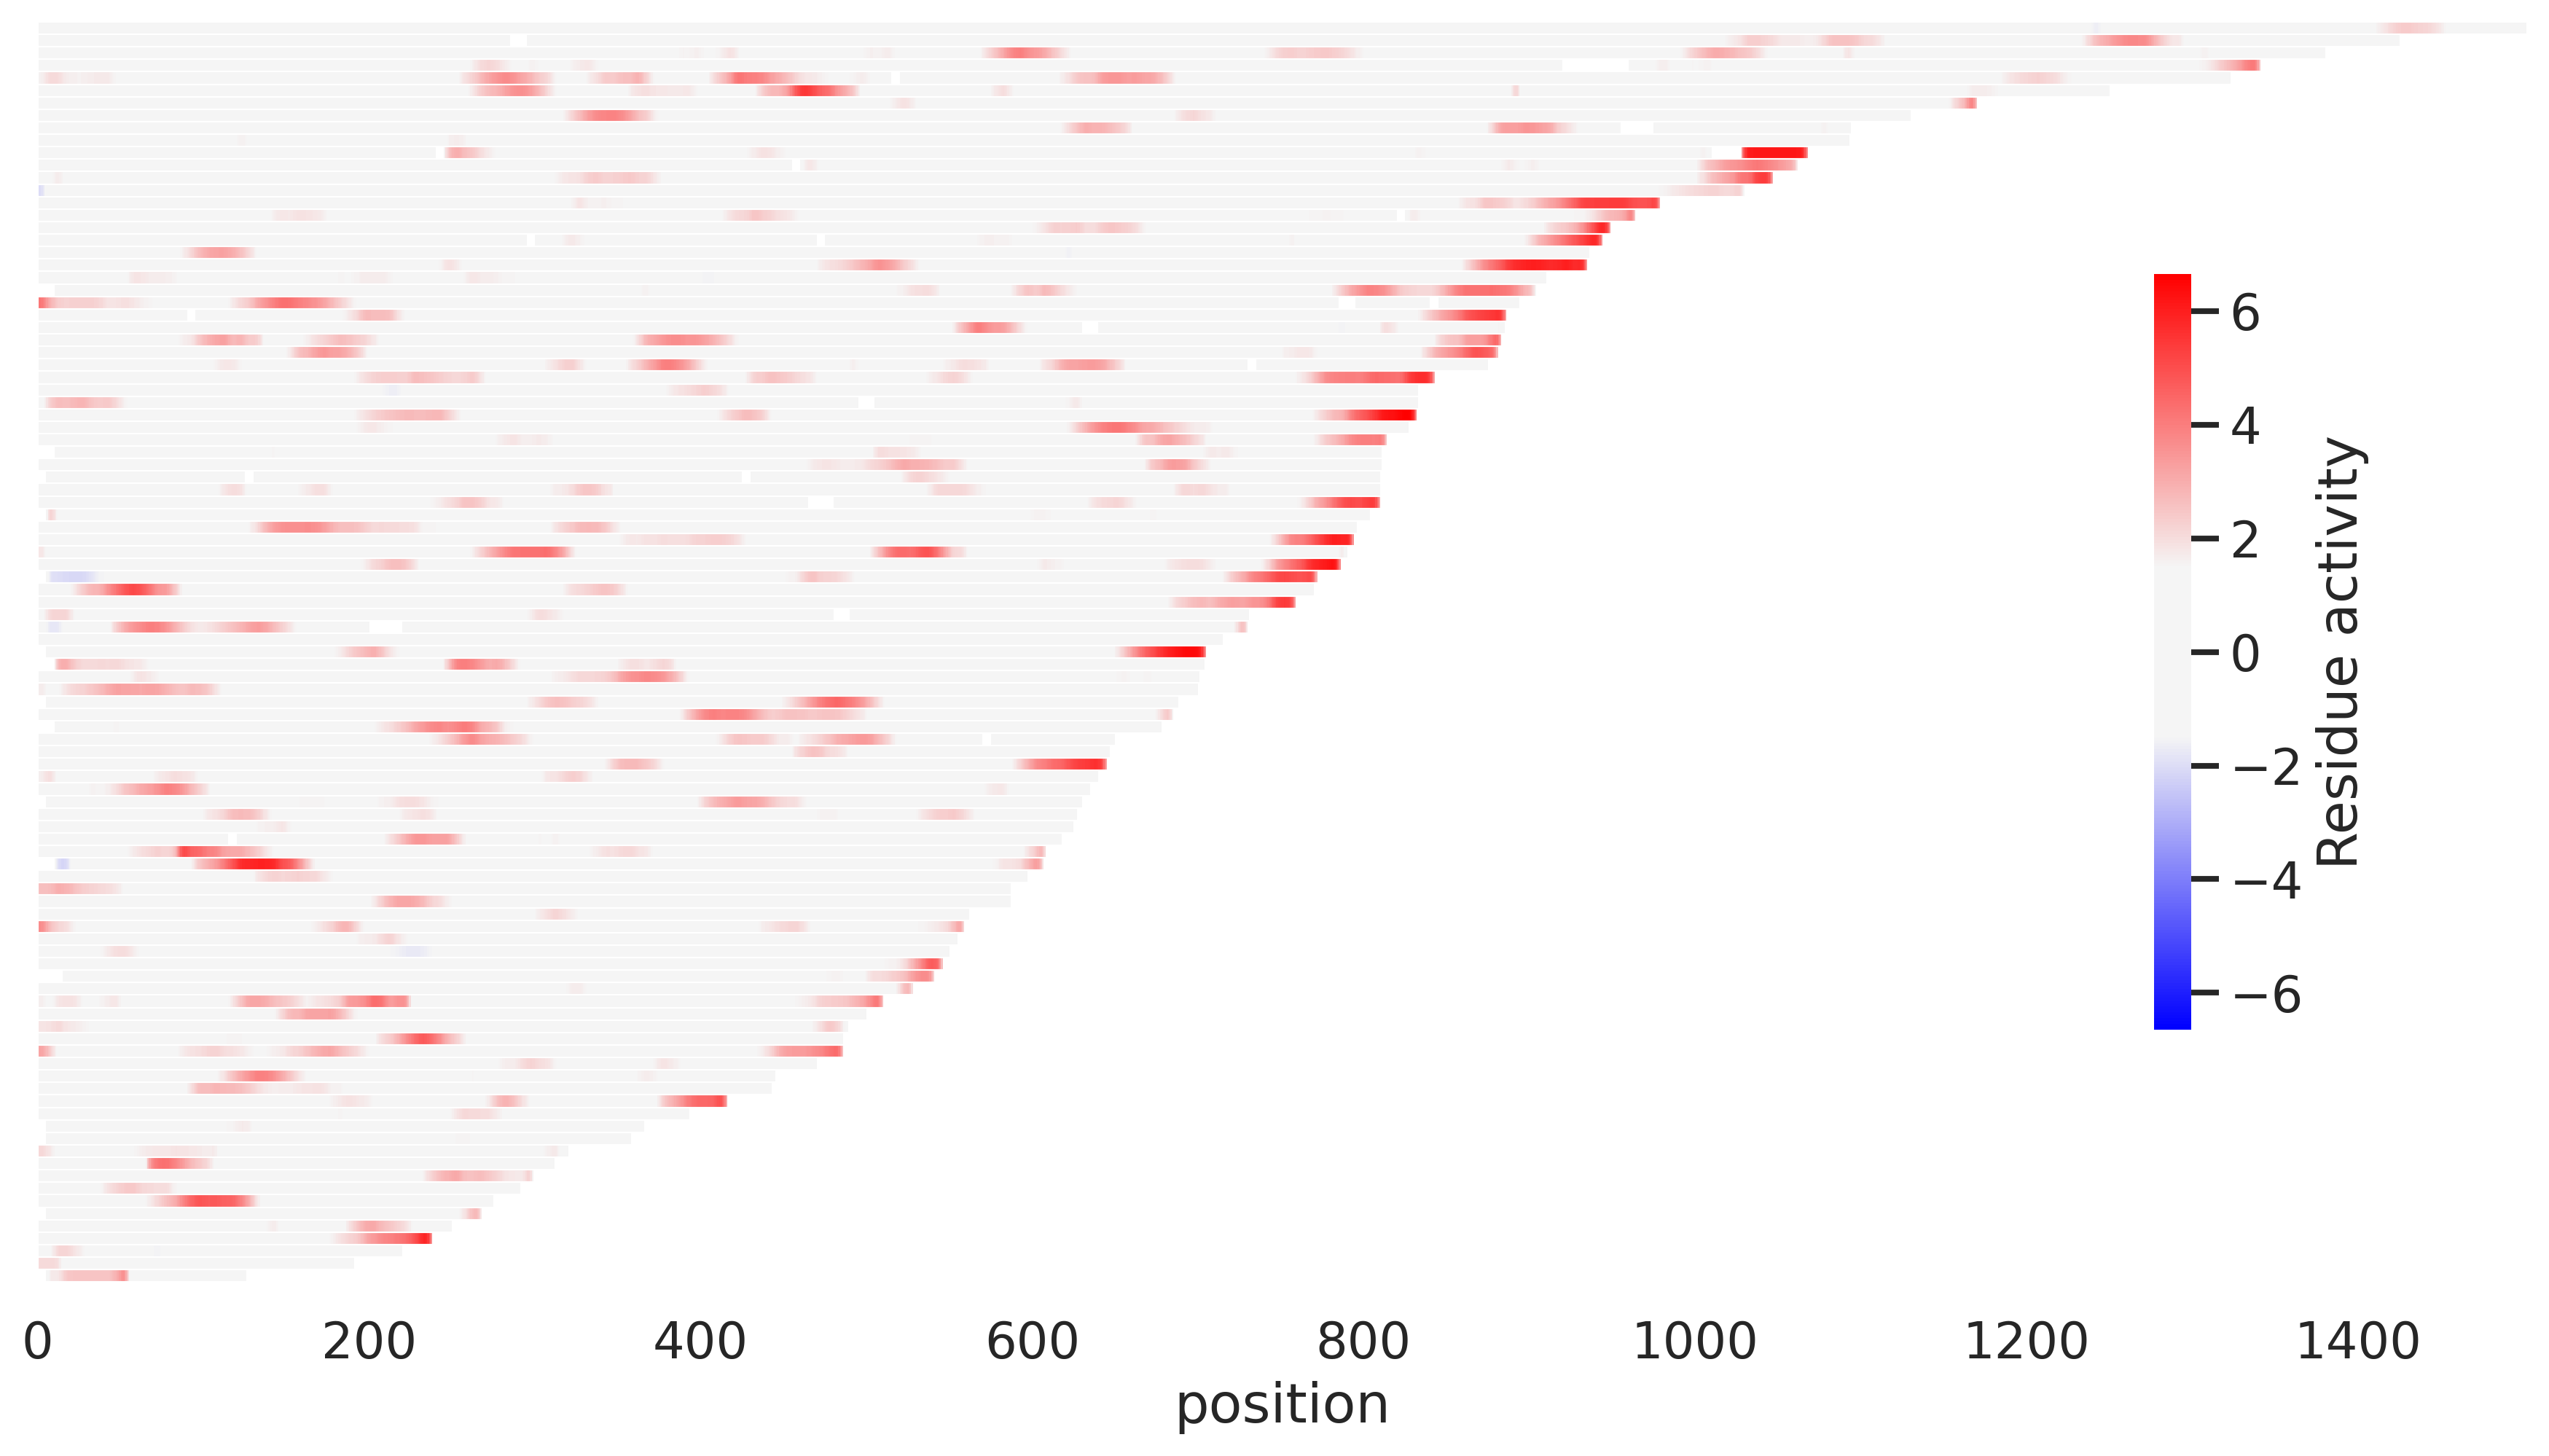

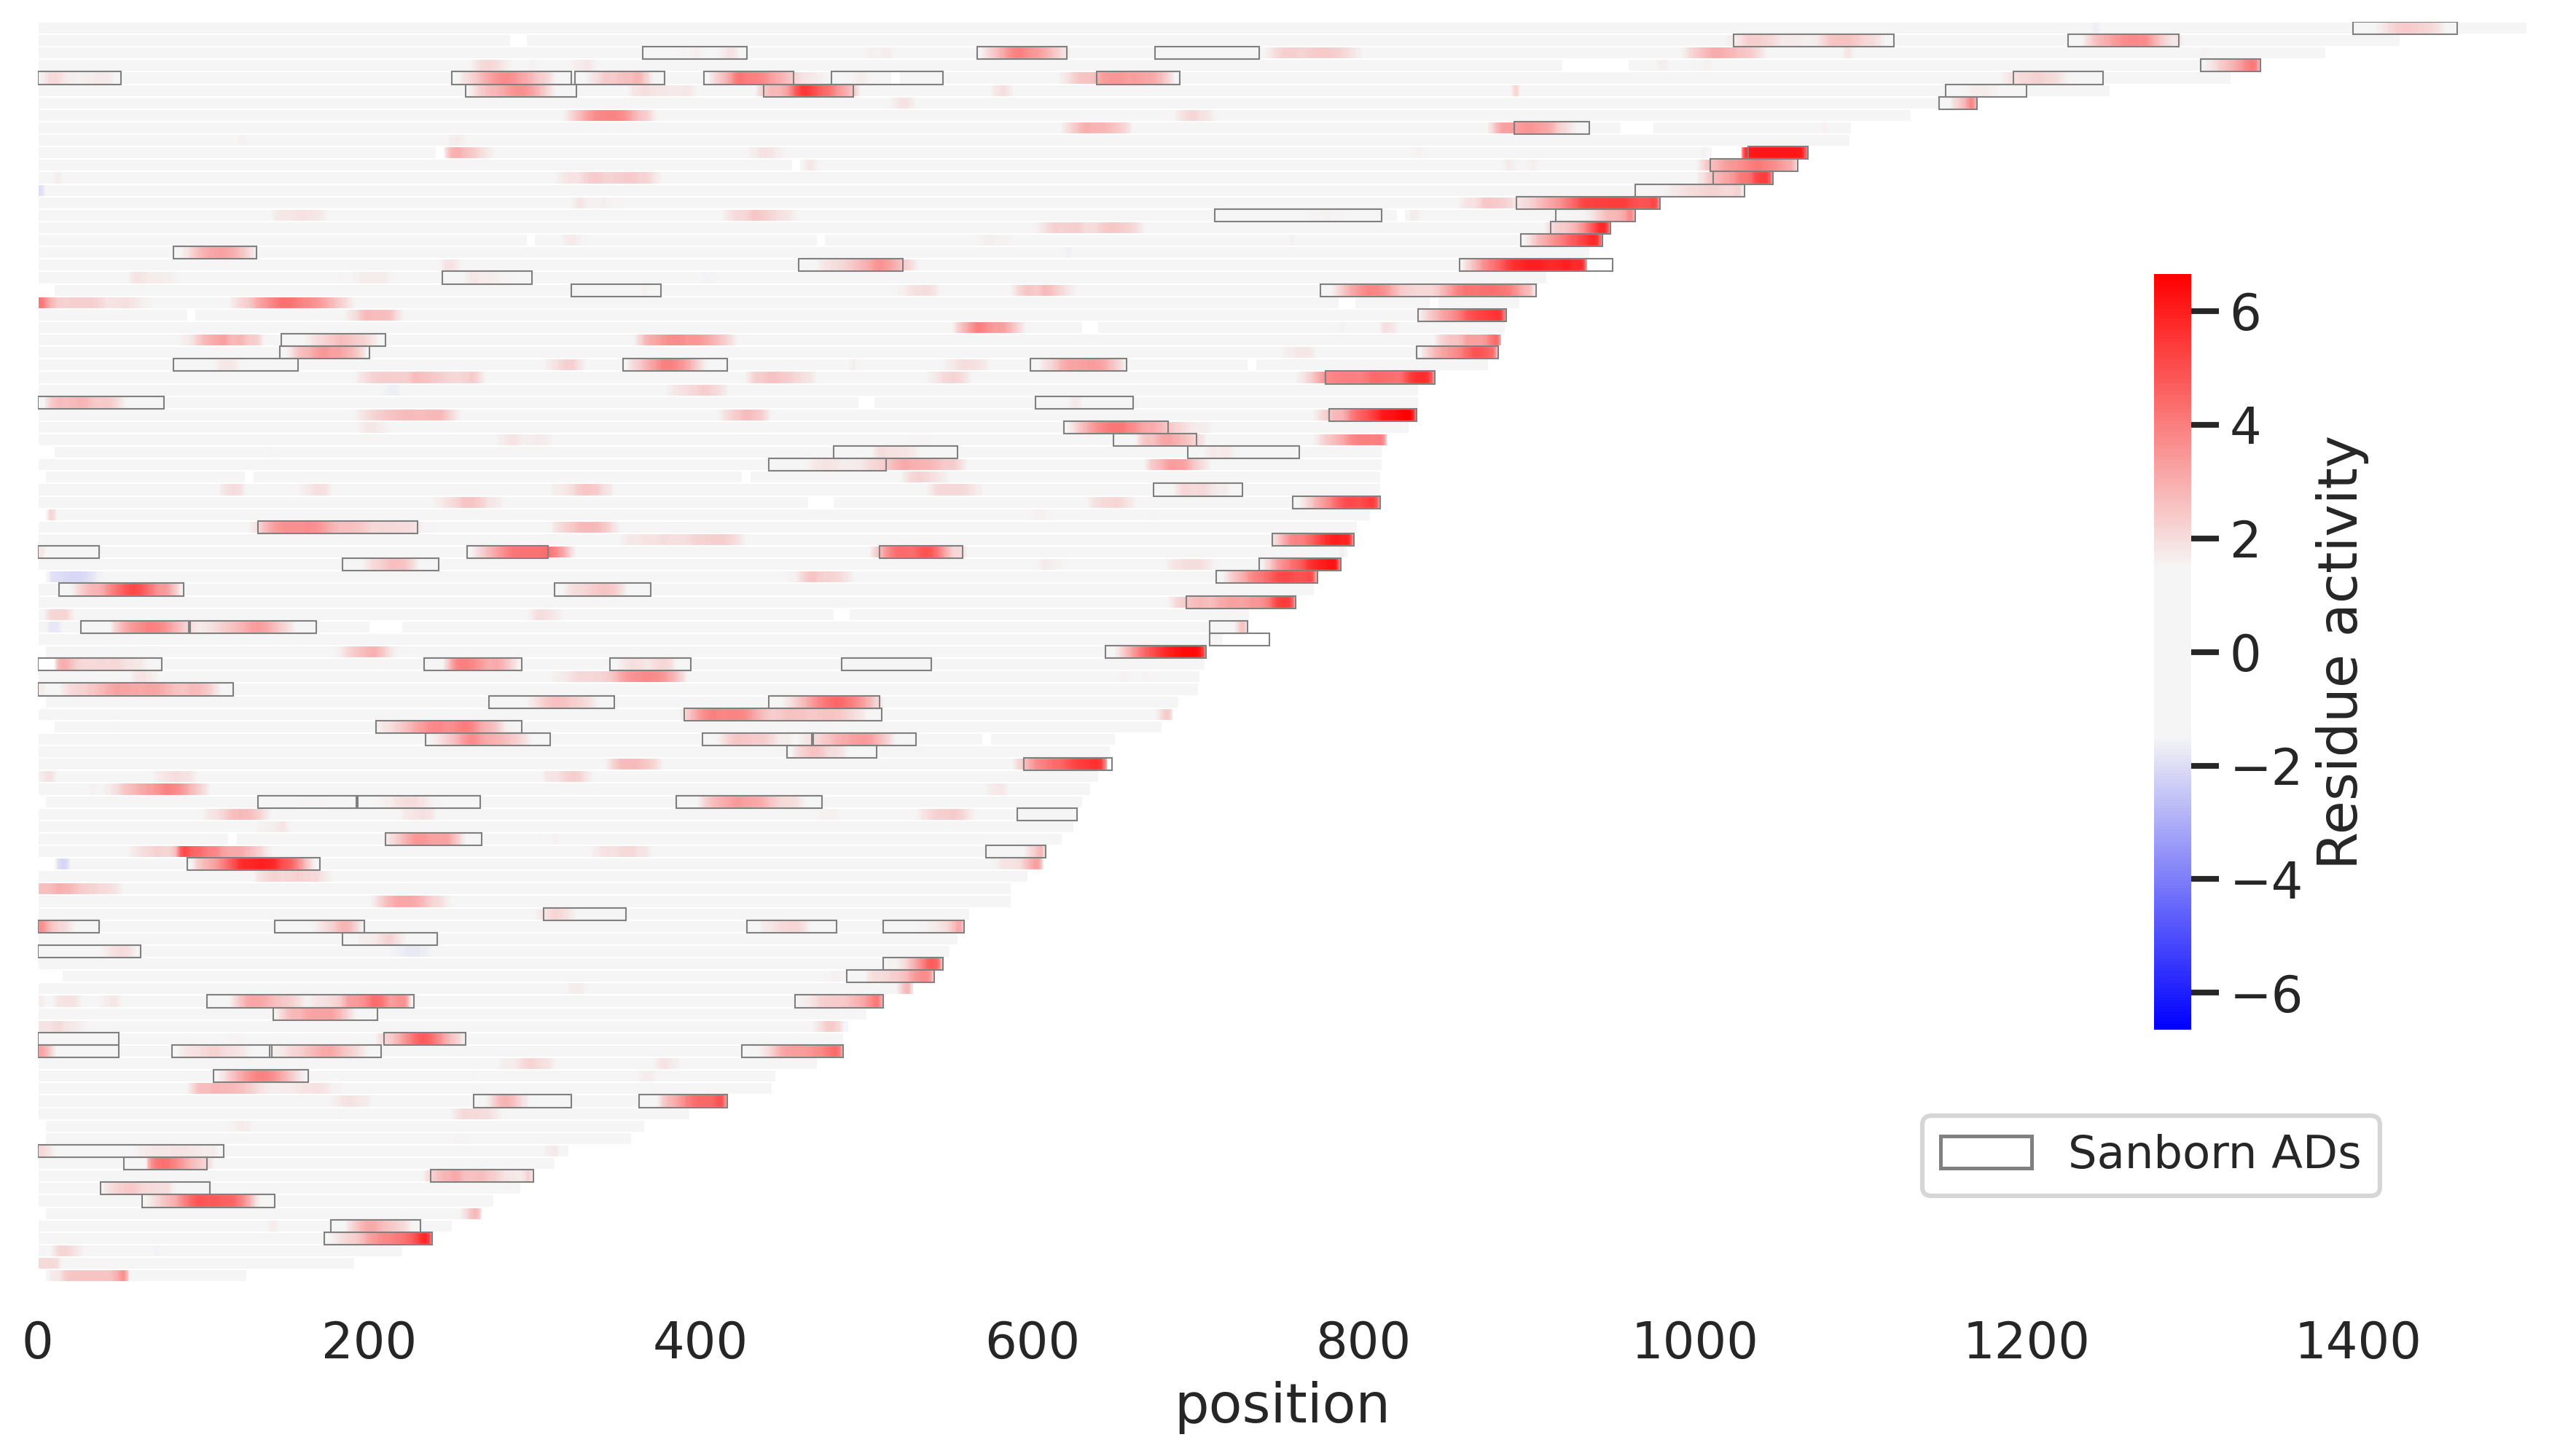

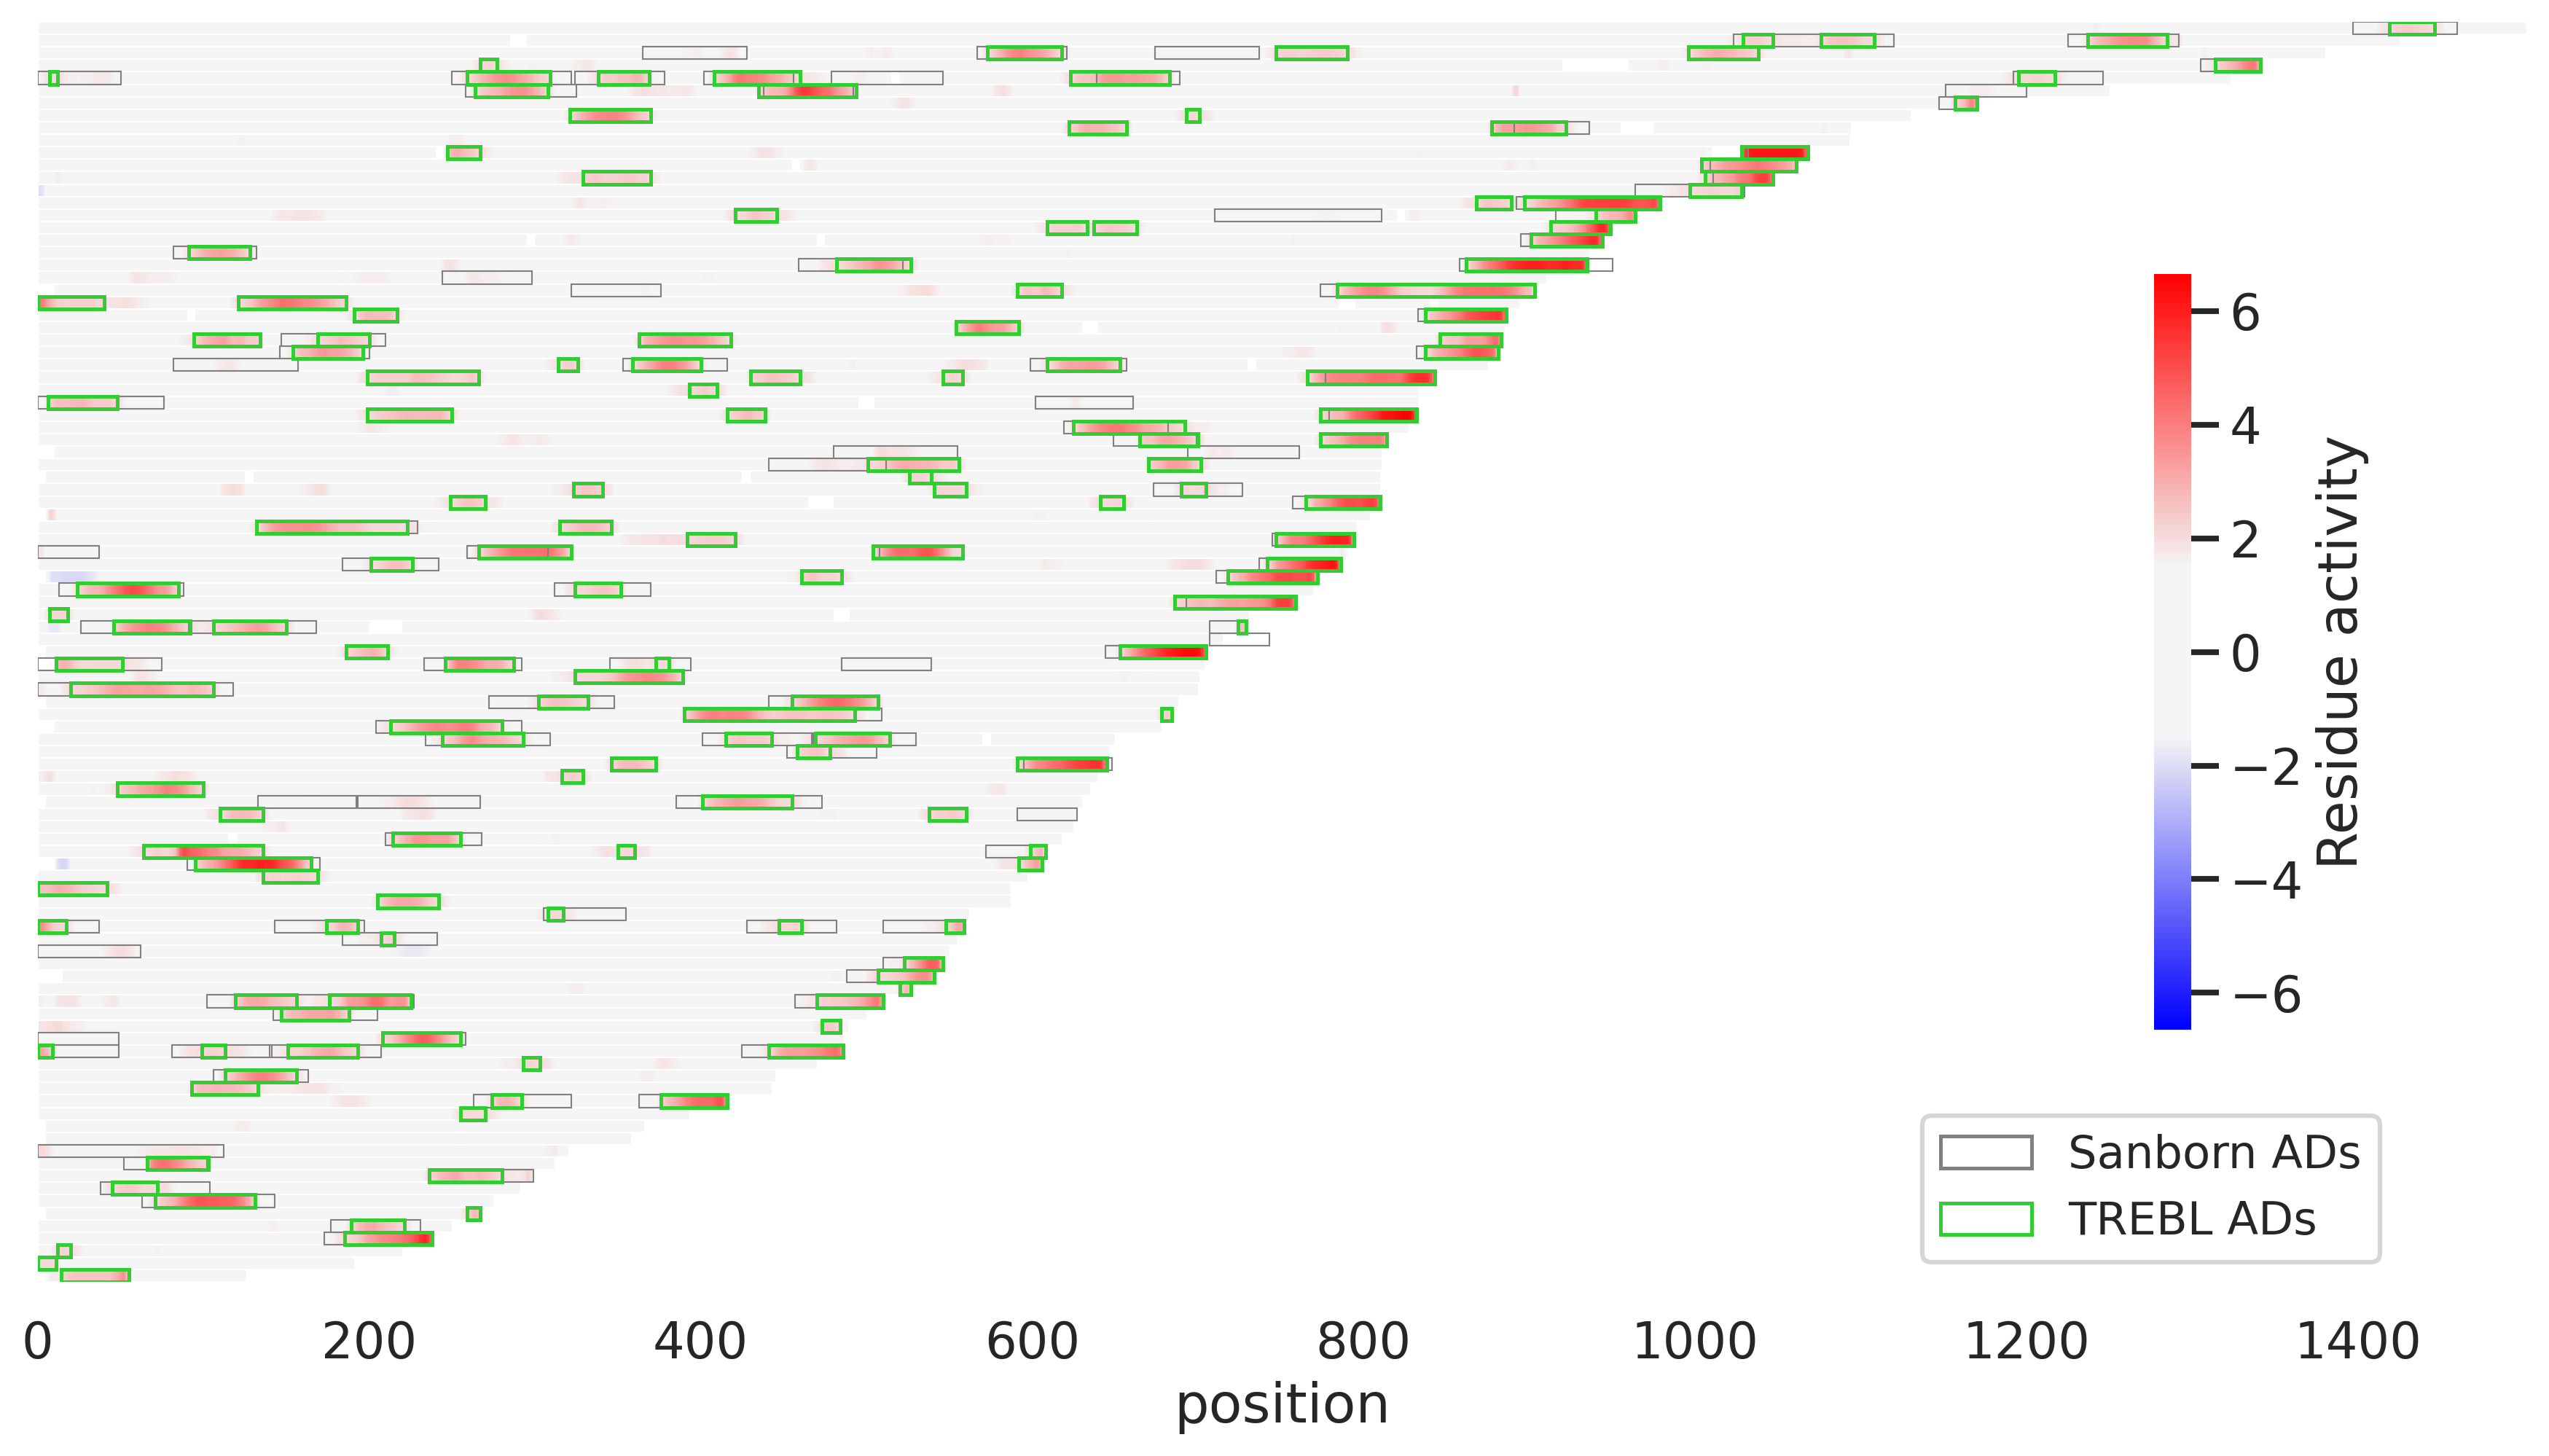

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle, Patch
import seaborn as sns

sns.set_context('talk')

# --- Prepare normalized colormap
data_min = np.nanmin(filtered_heatmap.values)
data_max = np.nanmax(filtered_heatmap.values)
lim = max(abs(data_min), abs(data_max))
norm = Normalize(vmin=-lim, vmax=lim)

neg_thresh = -1.5
pos_thresh = 1.5
p_neg = norm(neg_thresh)
p_pos = norm(pos_thresh)

cmap = LinearSegmentedColormap.from_list(
    "custom_blue_gray_red",
    [
        (0.0, "blue"),
        (p_neg, "whitesmoke"),
        (p_pos, "whitesmoke"),
        (1.0, "red")
    ]
)

# --- Helper function to plot heatmap with optional boxes
def plot_heatmap(filtered_heatmap, show_sanborn=False, show_trebl=False, figsize=(12,7), dpi=300):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    # Plot heatmap
    hm = sns.heatmap(
        filtered_heatmap,
        cmap=cmap,
        norm=norm,
        linewidths=0,
        cbar_kws={"label": "Residue activity", "shrink": 0.6, "pad" : -0.15},
        ax=ax
    )

    # --- White border around each TF row
    for row_idx in range(len(filtered_heatmap.index)):
        rect = Rectangle(
            (0, row_idx),
            width=filtered_heatmap.shape[1],
            height=1,
            edgecolor="white",
            facecolor="none",
            lw=0.5
        )
        ax.add_patch(rect)
        
    # Optional: Sanborn boxes
    if show_sanborn:
        for _, ad in sanborn_ADs.iterrows():
            uniprot = ad["uniprotID"]
            if uniprot not in filtered_heatmap.index:
                continue
            row_idx = filtered_heatmap.index.get_loc(uniprot)
            start, end = ad["start"], ad["stop"]
            rect = Rectangle(
                (start, row_idx),
                width=end-start+1,
                height=1,
                edgecolor="gray",
                facecolor="none",
                lw=0.5
            )
            ax.add_patch(rect)
    
    # Optional: TREBL boxes
    if show_trebl:
        for row_idx, uniprot in enumerate(filtered_heatmap.index):
            row_data = filtered_heatmap.loc[uniprot].values
            above_thresh = row_data > 2
            in_region = False
            start_idx = None
            for i, val in enumerate(above_thresh):
                if val and not in_region:
                    in_region = True
                    start_idx = i
                elif not val and in_region:
                    in_region = False
                    if i - start_idx >= 5:
                        rect = Rectangle(
                            (start_idx, row_idx),
                            width=i - start_idx,
                            height=1,
                            edgecolor="limegreen",
                            facecolor="none",
                            lw=1.2
                        )
                        ax.add_patch(rect)
            if in_region and len(row_data) - start_idx >= 5:
                rect = Rectangle(
                    (start_idx, row_idx),
                    width=len(row_data) - start_idx,
                    height=1,
                    edgecolor="limegreen",
                    facecolor="none",
                    lw=0.75
                )
                ax.add_patch(rect)
    
    # Axes and ticks
    ax.set_yticklabels([])
    ax.set_ylabel("")
    n_cols = filtered_heatmap.shape[1]
    xticks = np.arange(0, n_cols, 200)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks)
    plt.xticks(rotation=0)
    
    # Legend if boxes are shown
    legend_handles = []
    if show_sanborn:
        legend_handles.append(Patch(edgecolor="gray", facecolor="none", lw=1.2, label="Sanborn ADs"))
    if show_trebl:
        legend_handles.append(Patch(edgecolor="limegreen", facecolor="none", lw=1.2, label="TREBL ADs"))
    if legend_handles:
        ax.legend(handles=legend_handles, loc="upper right", fontsize='small',
                  bbox_to_anchor=(0.95, 0.15), frameon=True, facecolor="white")
    
    plt.tight_layout()
    return fig, ax

# --- Plot versions
fig1, ax1 = plot_heatmap(filtered_heatmap, show_sanborn=False, show_trebl=False)  # Heatmap only
fig2, ax2 = plot_heatmap(filtered_heatmap, show_sanborn=True, show_trebl=False)   # Heatmap + Sanborn
fig3, ax3 = plot_heatmap(filtered_heatmap, show_sanborn=True, show_trebl=True)    # Heatmap + Sanborn + TREBL